In [24]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
le = pd.read_csv('cleaned_life_expectancy_data.csv')


In [26]:
# 1. Сводная информация о данных
print("Размеры датасета:", le.shape)
print("\nОбщая информация:")
le.info()
print("\nПропущенные значения:")
print(le.isnull().sum())


Размеры датасета: (1849, 22)

Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1849 entries, 0 to 1848
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   1849 non-null   object 
 1   Year                      1849 non-null   int64  
 2   Status                    1849 non-null   object 
 3   Life_Expectancy           1849 non-null   float64
 4   Adult_Mortality           1849 non-null   float64
 5   Infant_Deaths             1849 non-null   int64  
 6   Alcohol                   1849 non-null   float64
 7   Percentage_Exp            1849 non-null   float64
 8   HepatitisB                1849 non-null   float64
 9   Measles                   1849 non-null   int64  
 10  BMI                       1849 non-null   float64
 11  Under_Five_Deaths         1849 non-null   int64  
 12  Polio                     1849 non-null   float64
 13  Tot_Exp        

In [27]:
# 2. Описание числовых столбцов
numerical_columns = le.select_dtypes(include=['float64', 'int64']).columns
print("\nСводная статистика числовых данных:")
print(le[numerical_columns].describe())



Сводная статистика числовых данных:
              Year  Life_Expectancy  Adult_Mortality  Infant_Deaths  \
count  1849.000000      1849.000000      1849.000000    1849.000000   
mean   2006.964846        67.865224       175.843699      37.090860   
std       4.325545         9.701858       131.349571     138.958391   
min    2000.000000        36.300000         1.000000       0.000000   
25%    2003.000000        61.400000        76.000000       1.000000   
50%    2007.000000        69.700000       154.000000       4.000000   
75%    2011.000000        74.600000       247.000000      25.000000   
max    2015.000000        89.000000       723.000000    1800.000000   

           Alcohol  Percentage_Exp   HepatitisB        Measles          BMI  \
count  1849.000000     1849.000000  1849.000000    1849.000000  1849.000000   
mean      4.374903      677.262172    73.714440    2808.837750    36.133748   
std       3.944041     1757.413463    29.006187   12367.835732    19.728856   
min    

In [28]:
le.describe()

,Year,Life_Expectancy,Adult_Mortality,Infant_Deaths,Alcohol,Percentage_Exp,HepatitisB,Measles,BMI,Under_Five_Deaths,Polio,Tot_Exp,Diphtheria,HIV/AIDS,GDP,Population,thinness_1to19_years,thinness_5to9_years,Income_Comp_Of_Resources,Schooling
count,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,1.849000e+03,1849.000000,1849.000000,1849.000000,1849.000000
mean,2006.964846,67.865224,175.843699,37.090860,4.374903,677.262172,73.714440,2808.837750,36.133748,51.554895,80.451595,5.896036,80.571660,2.252190,5323.805606,1.323521e+07,5.215684,5.285506,0.600726,11.599405
std,4.325545,9.701858,131.349571,138.958391,3.944041,1757.413463,29.006187,12367.835732,19.728856,188.865542,24.008881,2.302596,24.104915,5.871455,11448.151468,6.120742e+07,4.778532,4.875135,0.206114,3.225270
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,2.000000,0.000000,1.400000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2003.000000,61.400000,76.000000,1.000000,0.790000,29.520799,64.000000,0.000000,18.000000,1.000000,74.000000,4.360000,75.000000,0.100000,386.328828,1.912660e+05,1.700000,1.700000,0.469000,9.700000
50%,2007.000000,69.700000,154.000000,4.000000,3.640000,103.371069,86.000000,22.000000,37.800000,4.000000,91.000000,5.780000,91.000000,0.100000,1326.668820,1.396985e+06,3.500000,3.500000,0.644000,11.800000
75%,2011.000000,74.600000,247.000000,25.000000,7.040000,469.390419,95.000000,535.000000,54.900000,37.000000,96.000000,7.390000,96.000000,1.500000,4437.178680,7.815949e+06,7.700000,7.800000,0.741000,13.700000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,18961.348600,99.000000,212183.000000,76.700000,2500.000000,99.000000,14.390000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.936000,20.700000


In [29]:
#Переименовываем столбцы
le.rename(columns={" BMI ":"BMI","Life expectancy ":"Life_Expectancy","Adult Mortality":"Adult_Mortality",
                   "infant deaths":"Infant_Deaths","percentage expenditure":"Percentage_Exp","Hepatitis B":"HepatitisB",
                  "Measles ":"Measles"," BMI ":"BMI","under-five deaths ":"Under_Five_Deaths","Diphtheria ":"Diphtheria",
                  " HIV/AIDS":"HIV/AIDS"," thinness  1-19 years":"thinness_1to19_years"," thinness 5-9 years":"thinness_5to9_years","Income composition of resources":"Income_Comp_Of_Resources",
                   "Total expenditure":"Tot_Exp"}, inplace=True)

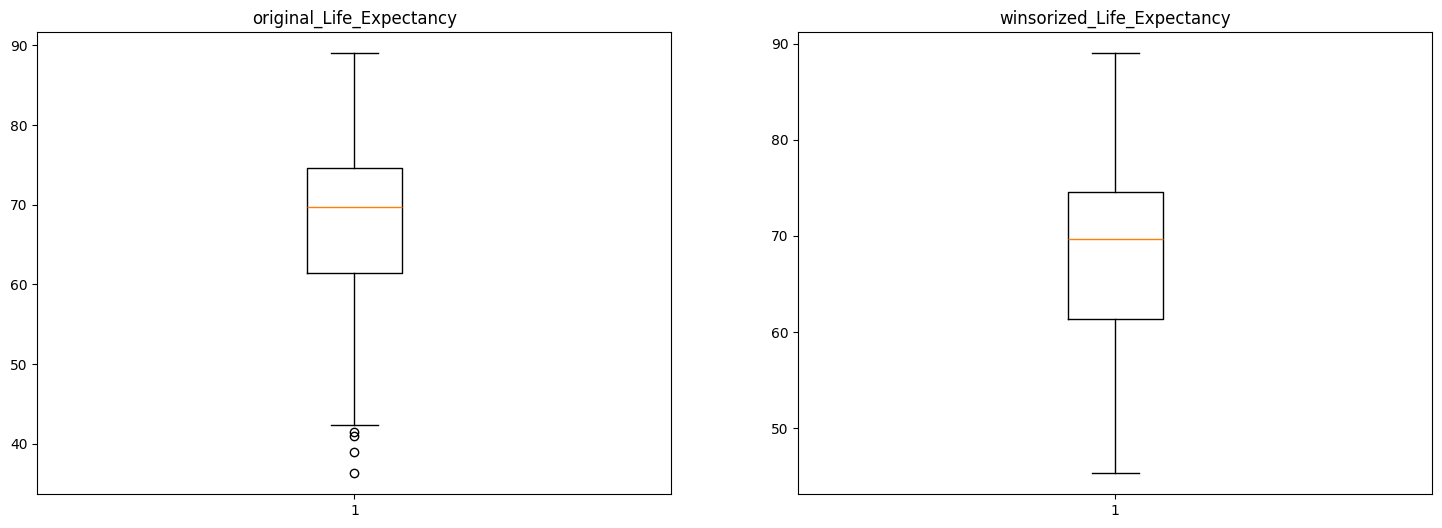

In [30]:
#Подчищаем такие значения, используя технику систематизации
from scipy.stats.mstats import winsorize
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_Life_Expectancy = le['Life_Expectancy']
plt.boxplot(original_Life_Expectancy)
plt.title("original_Life_Expectancy")

plt.subplot(1,2,2)
winsorized_Life_Expectancy = winsorize(le['Life_Expectancy'], (0.01, 0))
plt.boxplot(winsorized_Life_Expectancy)
plt.title("winsorized_Life_Expectancy")

plt.show()


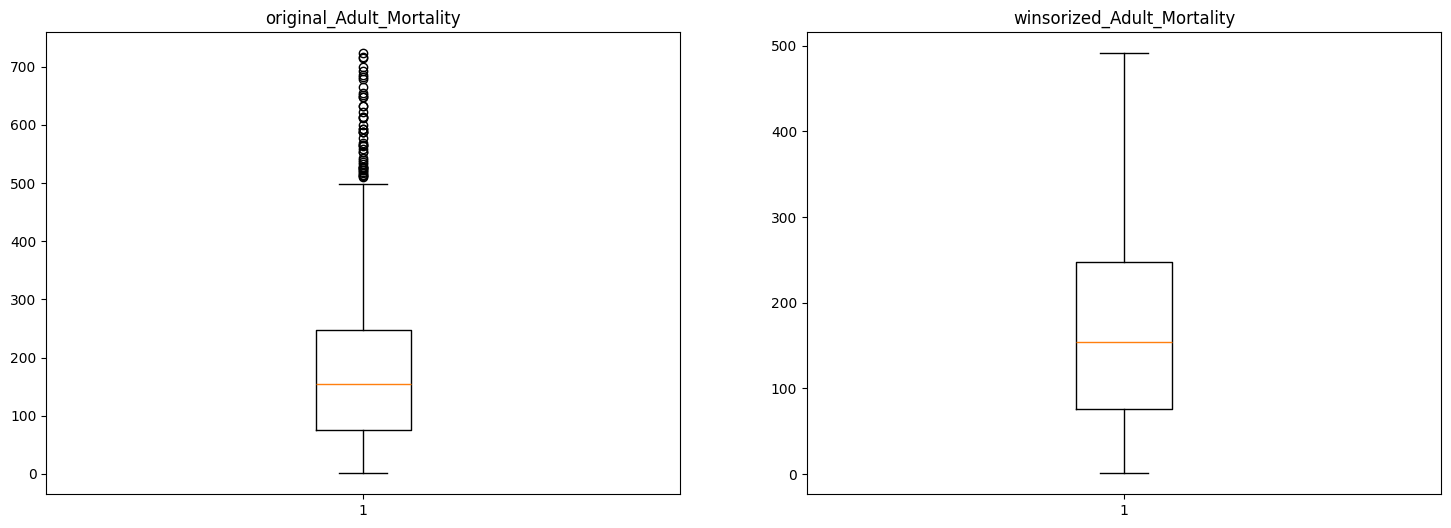

In [31]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_Adult_Mortality = le['Adult_Mortality']
plt.boxplot(original_Adult_Mortality)
plt.title("original_Adult_Mortality")

plt.subplot(1,2,2)
winsorized_Adult_Mortality = winsorize(le['Adult_Mortality'],(0,0.03))
plt.boxplot(winsorized_Adult_Mortality)
plt.title("winsorized_Adult_Mortality")

plt.show()

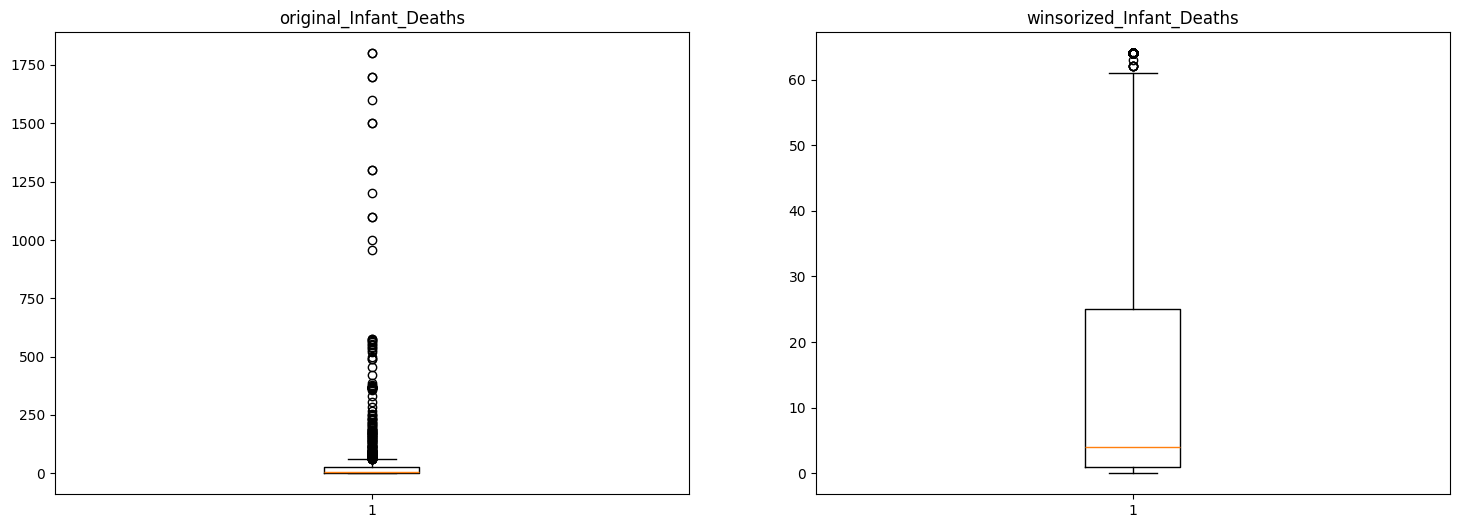

In [32]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_Infant_Deaths = le['Infant_Deaths']
plt.boxplot(original_Infant_Deaths)
plt.title("original_Infant_Deaths")

plt.subplot(1,2,2)
winsorized_Infant_Deaths = winsorize(le['Infant_Deaths'], limits=[0.0, 0.1])
plt.boxplot(winsorized_Infant_Deaths)
plt.title("winsorized_Infant_Deaths")

plt.show()

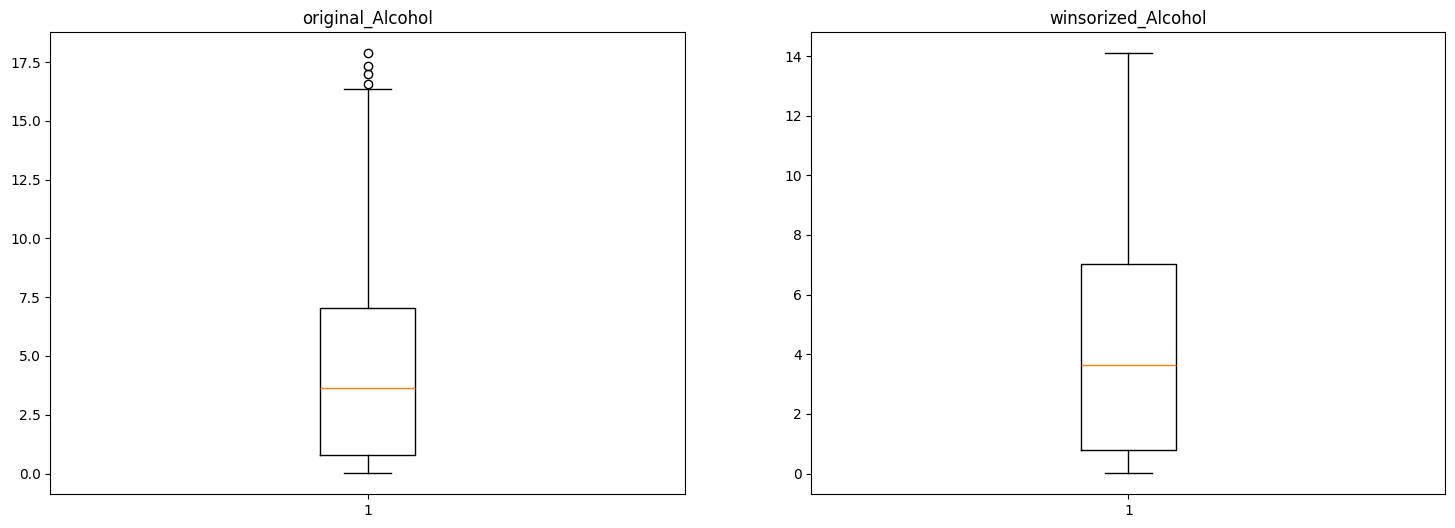

In [33]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_Alcohol = le['Alcohol']
plt.boxplot(original_Alcohol)
plt.title("original_Alcohol")

plt.subplot(1,2,2)
winsorized_Alcohol = winsorize(le['Alcohol'],(0,0.01))
plt.boxplot(winsorized_Alcohol)
plt.title("winsorized_Alcohol")

plt.show()

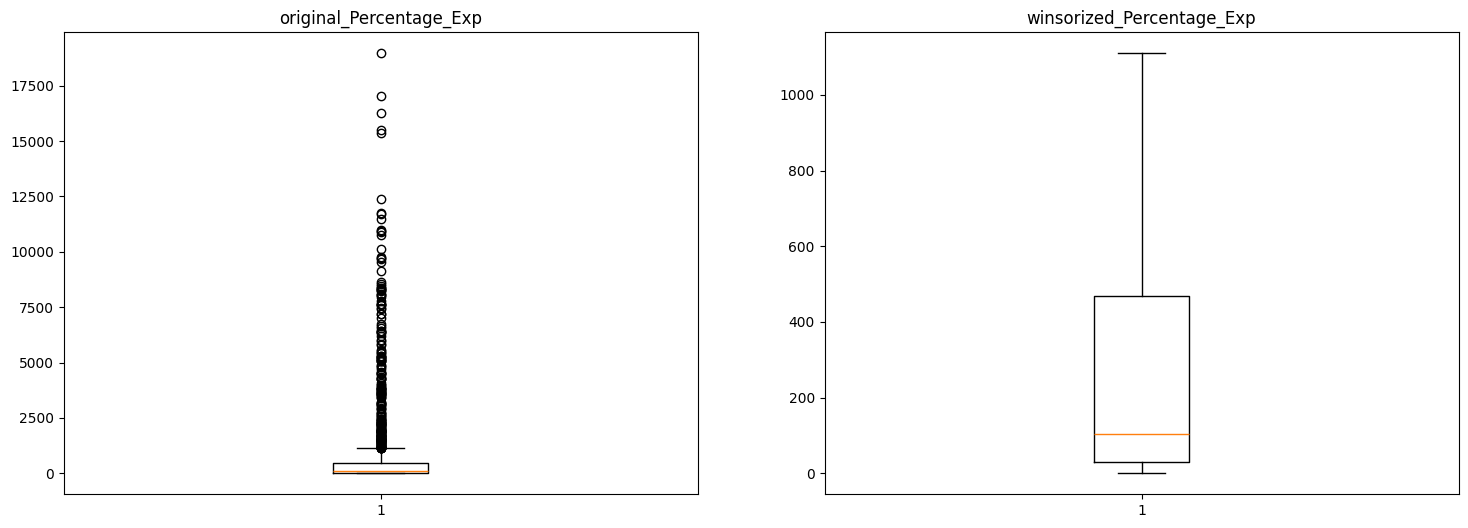

In [34]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_Percentage_Exp = le['Percentage_Exp']
plt.boxplot(original_Percentage_Exp)
plt.title("original_Percentage_Exp")

plt.subplot(1,2,2)
winsorized_Percentage_Exp = winsorize(le['Percentage_Exp'],(0,0.12))
plt.boxplot(winsorized_Percentage_Exp)
plt.title("winsorized_Percentage_Exp")

plt.show()

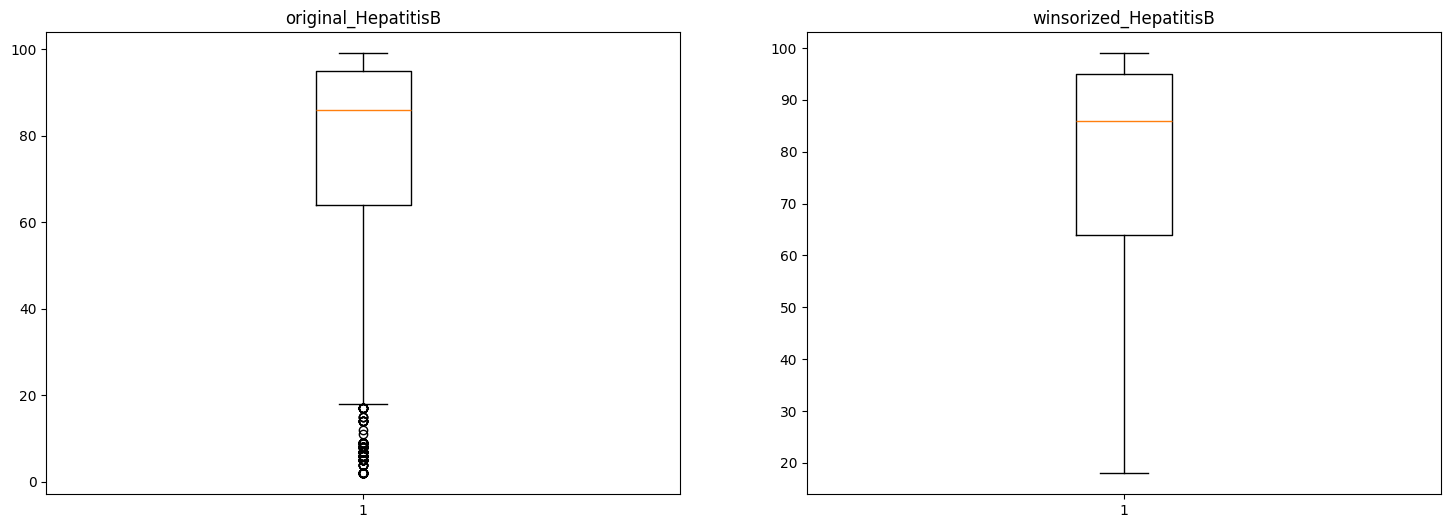

In [35]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_HepatitisB = le['HepatitisB']
plt.boxplot(original_HepatitisB)
plt.title("original_HepatitisB")

plt.subplot(1,2,2)
winsorized_HepatitisB = winsorize(le['HepatitisB'],(0.11,0))
plt.boxplot(winsorized_HepatitisB)
plt.title("winsorized_HepatitisB")

plt.show()

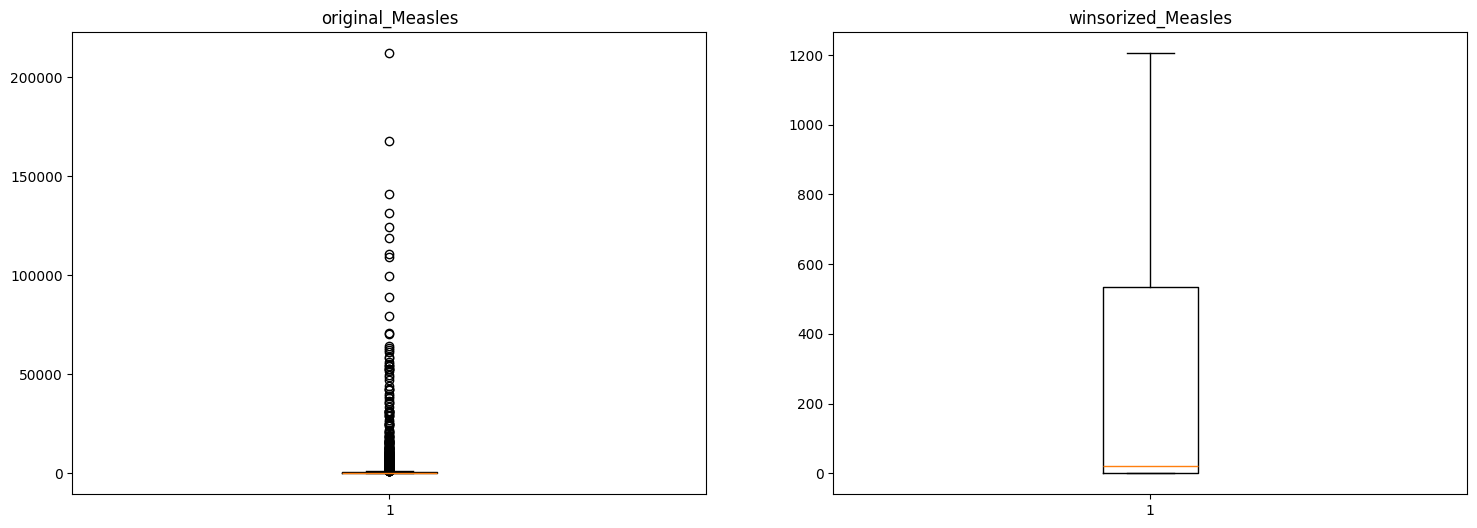

In [36]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_Measles = le['Measles']
plt.boxplot(original_Measles)
plt.title("original_Measles")

plt.subplot(1,2,2)
winsorized_Measles = winsorize(le['Measles'],(0,0.19))
plt.boxplot(winsorized_Measles)
plt.title("winsorized_Measles")

plt.show()

In [37]:
#Дропаем этот столбик, так как слишком большое процентное содержание выбросных значений
le = le.drop('Measles',axis=1)

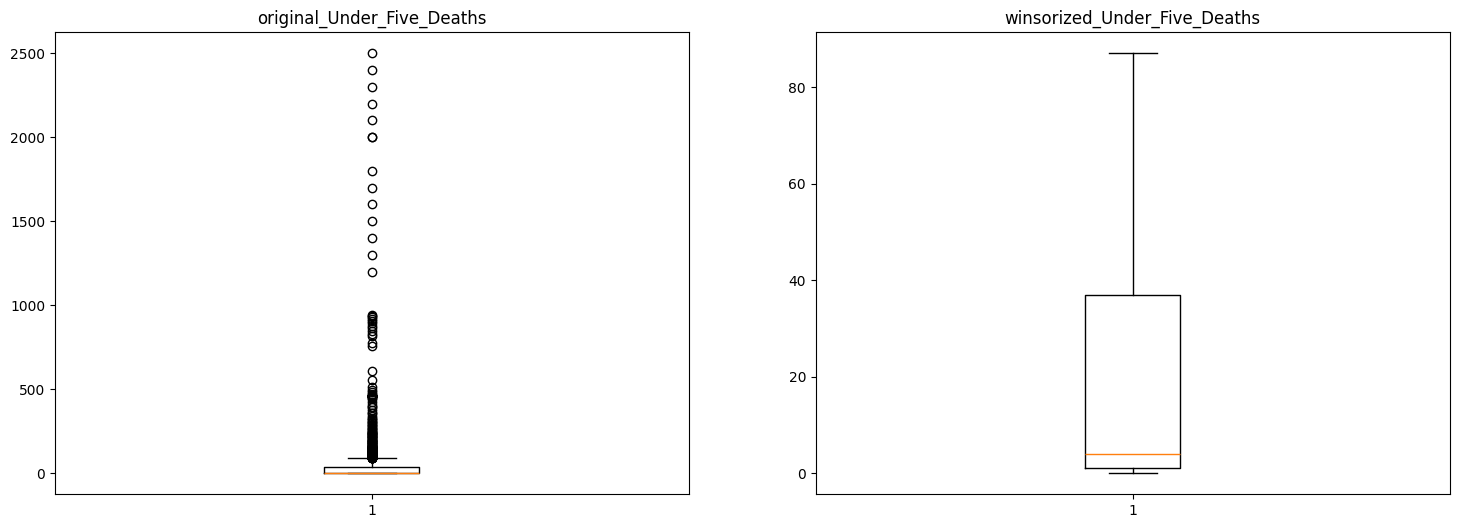

In [38]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_Under_Five_Deaths = le['Under_Five_Deaths']
plt.boxplot(original_Under_Five_Deaths)
plt.title("original_Under_Five_Deaths")

plt.subplot(1,2,2)
winsorized_Under_Five_Deaths = winsorize(le['Under_Five_Deaths'],(0,0.12))
plt.boxplot(winsorized_Under_Five_Deaths)
plt.title("winsorized_Under_Five_Deaths")

plt.show()

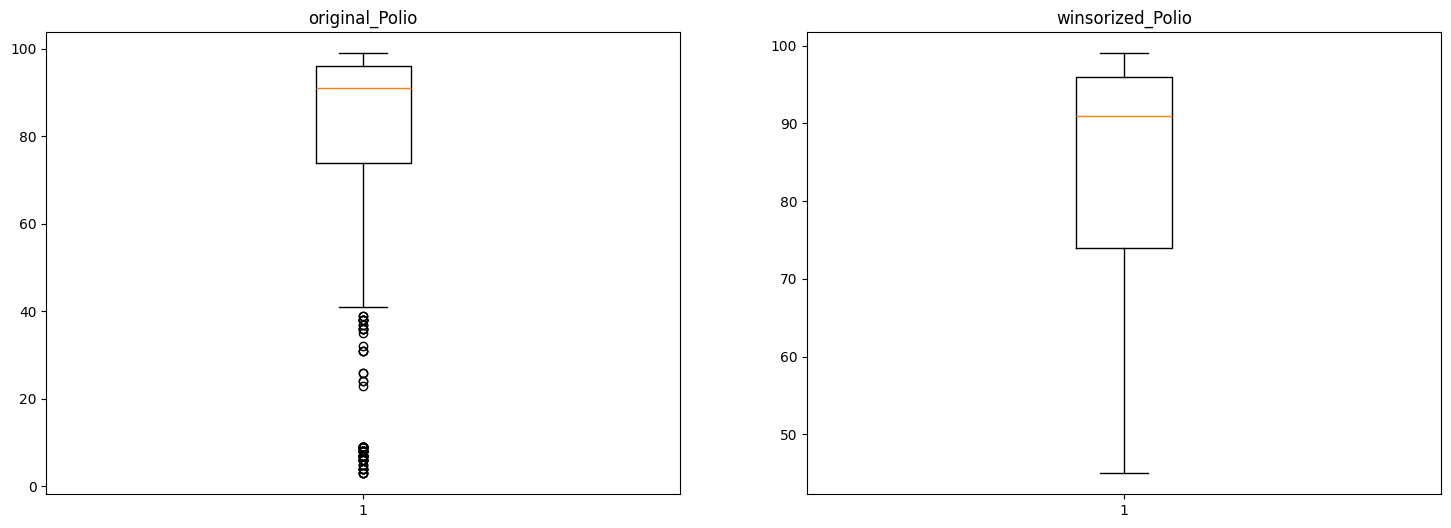

In [39]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_Polio = le['Polio']
plt.boxplot(original_Polio)
plt.title("original_Polio")

plt.subplot(1,2,2)
winsorized_Polio = winsorize(le['Polio'],(0.09,0))
plt.boxplot(winsorized_Polio)
plt.title("winsorized_Polio")

plt.show()

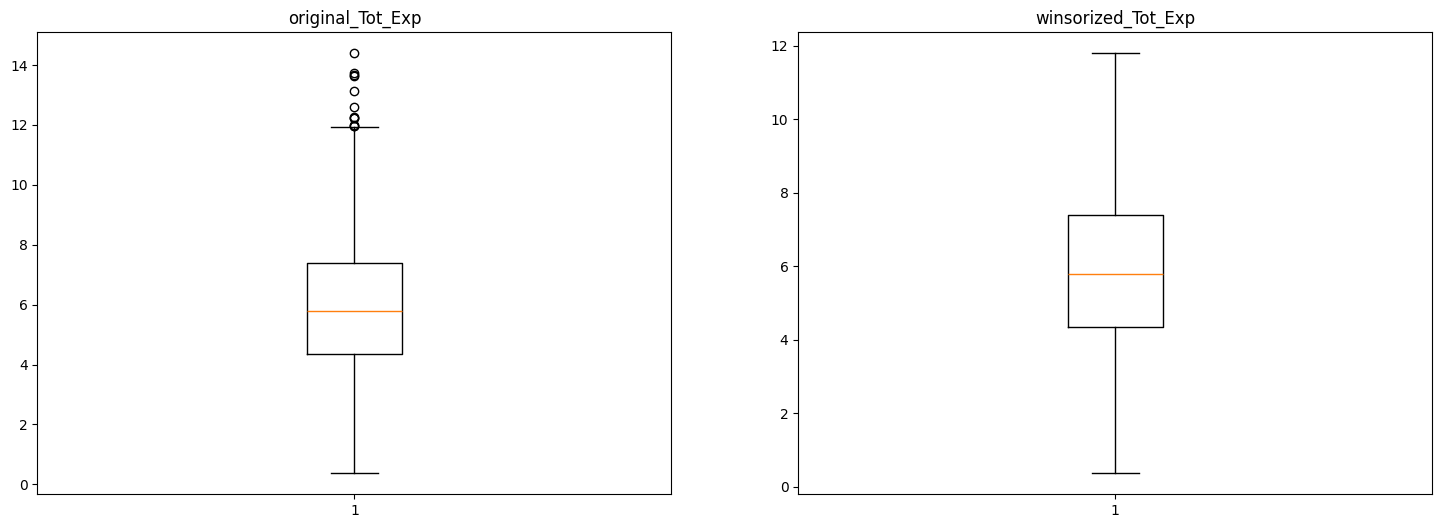

In [40]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_Tot_Exp = le['Tot_Exp']
plt.boxplot(original_Tot_Exp)
plt.title("original_Tot_Exp")

plt.subplot(1,2,2)
winsorized_Tot_Exp = winsorize(le['Tot_Exp'],(0,0.01))
plt.boxplot(winsorized_Tot_Exp)
plt.title("winsorized_Tot_Exp")

plt.show()

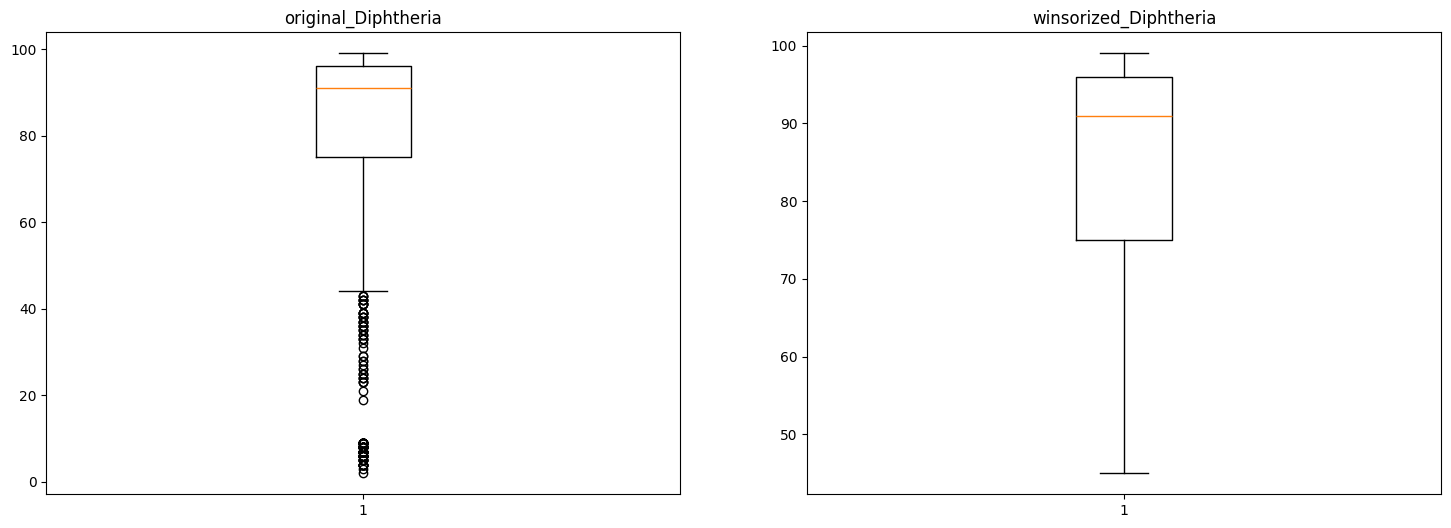

In [41]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_Diphtheria = le['Diphtheria']
plt.boxplot(original_Diphtheria)
plt.title("original_Diphtheria")

plt.subplot(1,2,2)
winsorized_Diphtheria = winsorize(le['Diphtheria'],(0.10,0))
plt.boxplot(winsorized_Diphtheria)
plt.title("winsorized_Diphtheria")

plt.show()

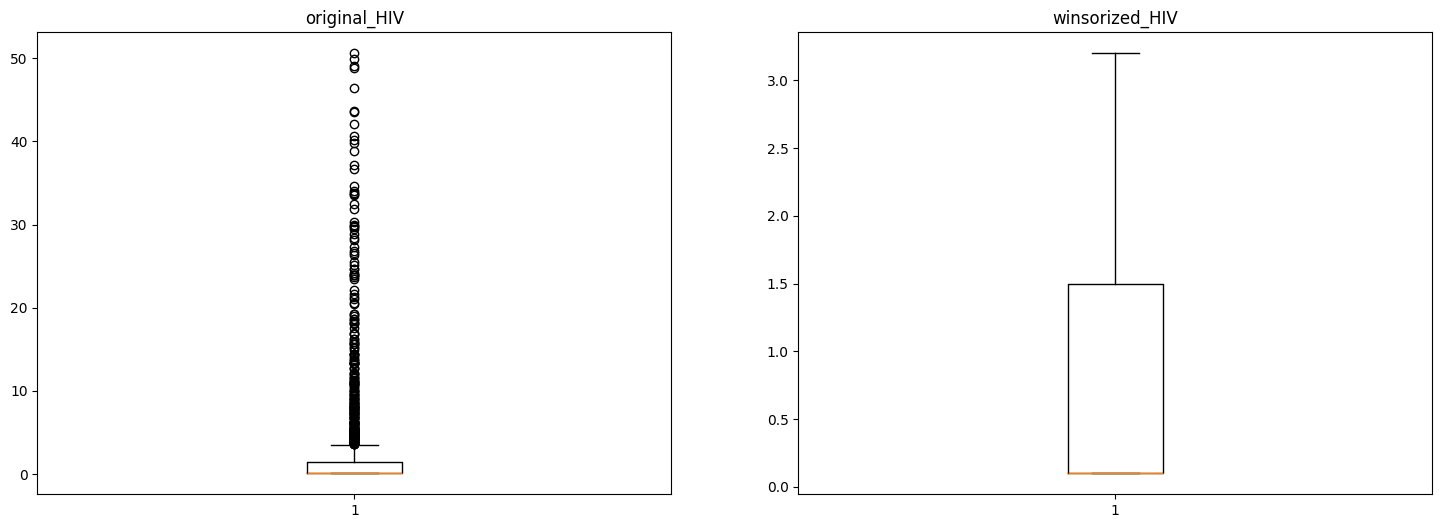

In [42]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_HIV = le['HIV/AIDS']
plt.boxplot(original_HIV)
plt.title("original_HIV")

plt.subplot(1,2,2)
winsorized_HIV = winsorize(le['HIV/AIDS'],(0,0.16))
plt.boxplot(winsorized_HIV)
plt.title("winsorized_HIV")

plt.show()

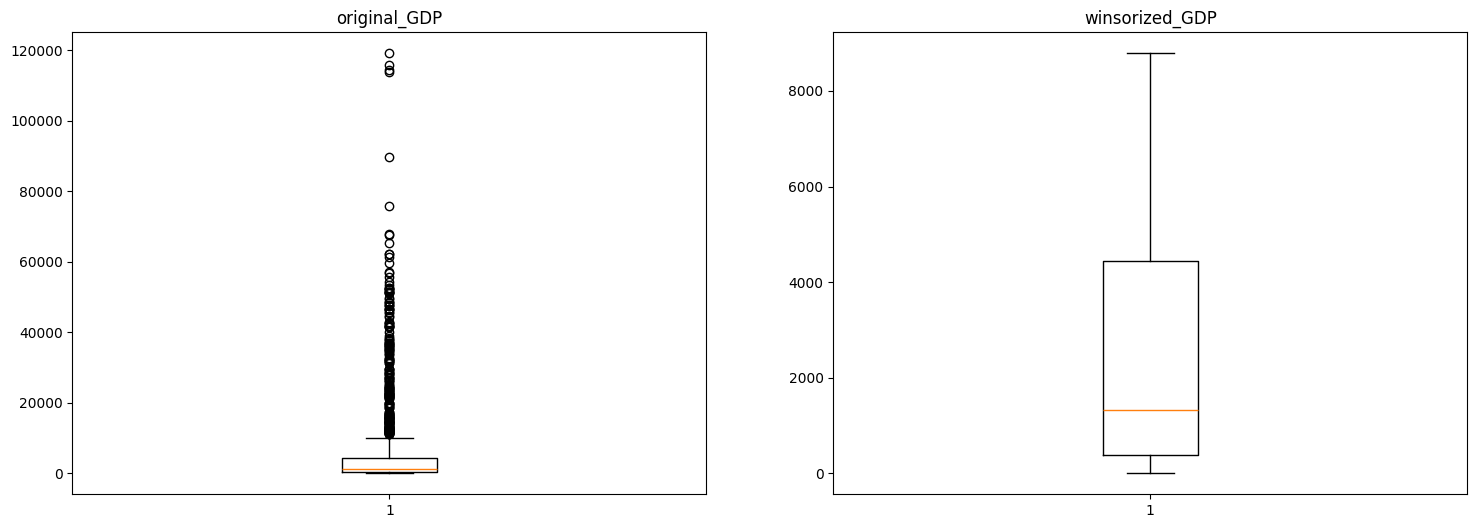

In [43]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_GDP = le['GDP']
plt.boxplot(original_GDP)
plt.title("original_GDP")

plt.subplot(1,2,2)
winsorized_GDP = winsorize(le['GDP'],(0,0.13))
plt.boxplot(winsorized_GDP)
plt.title("winsorized_GDP")

plt.show()

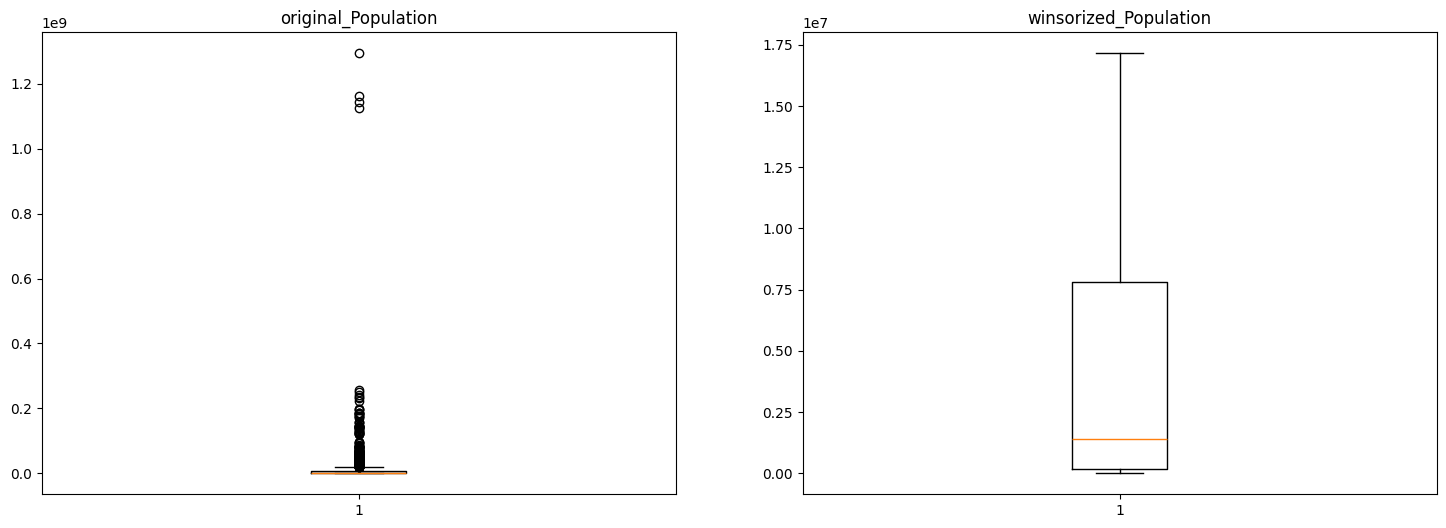

In [44]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_Population = le['Population']
plt.boxplot(original_Population)
plt.title("original_Population")

plt.subplot(1,2,2)
winsorized_Population = winsorize(le['Population'],(0,0.14))
plt.boxplot(winsorized_Population)
plt.title("winsorized_Population")

plt.show()

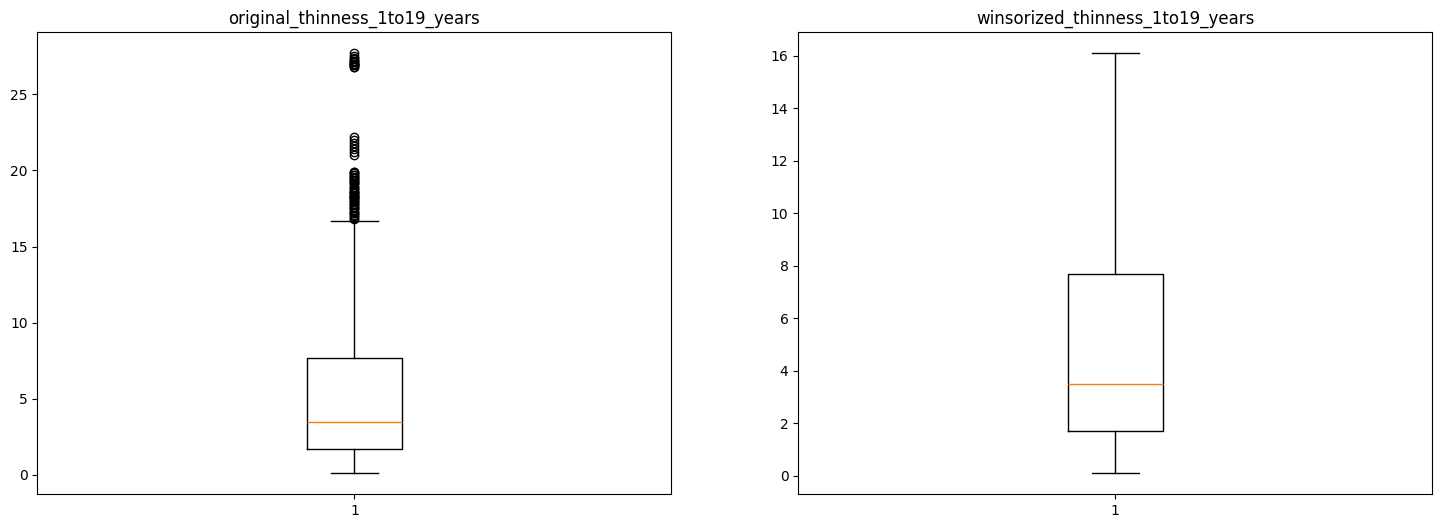

In [45]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_thinness_1to19_years = le['thinness_1to19_years']
plt.boxplot(original_thinness_1to19_years)
plt.title("original_thinness_1to19_years")

plt.subplot(1,2,2)
winsorized_thinness_1to19_years = winsorize(le['thinness_1to19_years'],(0,0.04))
plt.boxplot(winsorized_thinness_1to19_years)
plt.title("winsorized_thinness_1to19_years")

plt.show()

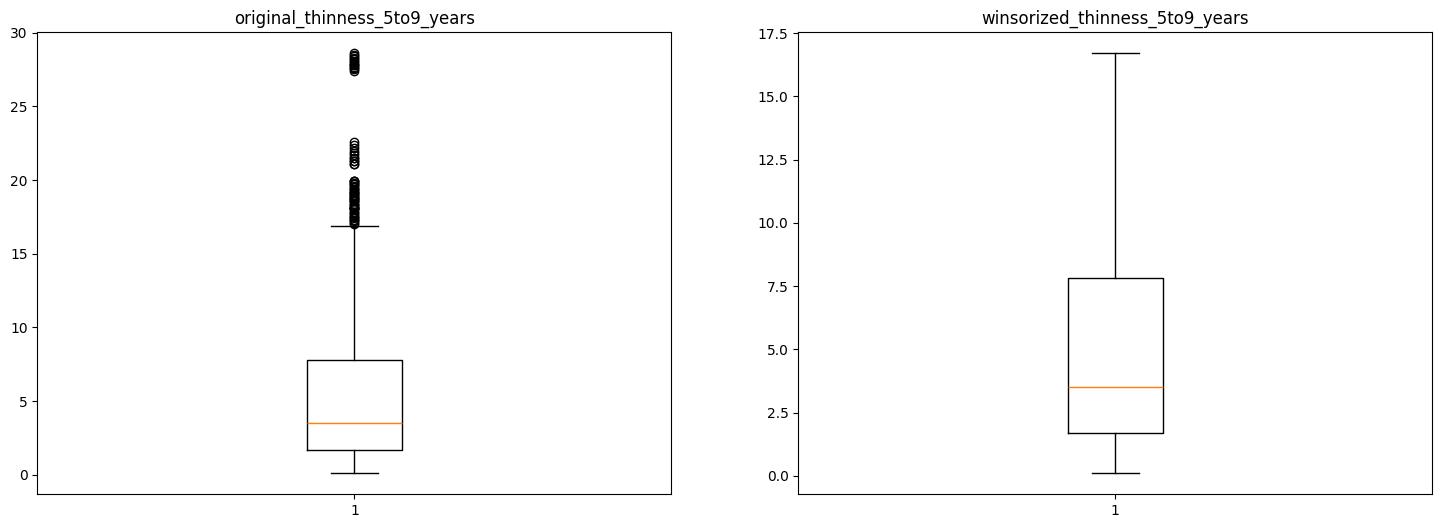

In [46]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_thinness_5to9_years = le['thinness_5to9_years']
plt.boxplot(original_thinness_5to9_years)
plt.title("original_thinness_5to9_years")

plt.subplot(1,2,2)
winsorized_thinness_5to9_years = winsorize(le['thinness_5to9_years'],(0,0.04))
plt.boxplot(winsorized_thinness_5to9_years)
plt.title("winsorized_thinness_5to9_years")

plt.show()

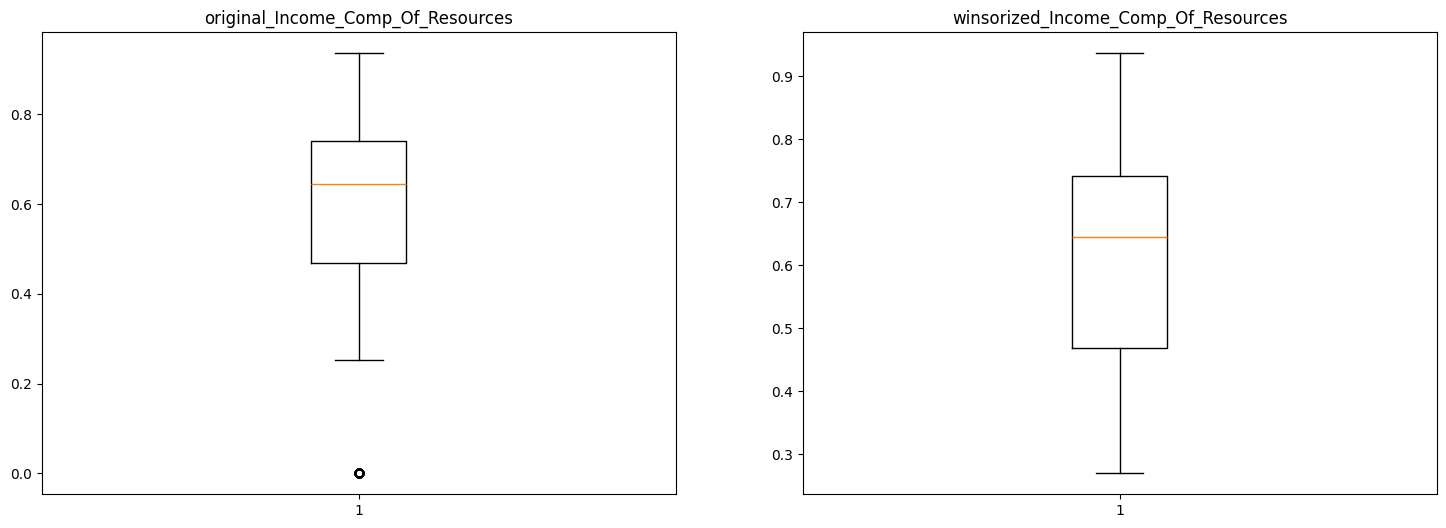

In [47]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_Income_Comp_Of_Resources = le['Income_Comp_Of_Resources']
plt.boxplot(original_Income_Comp_Of_Resources)
plt.title("original_Income_Comp_Of_Resources")

plt.subplot(1,2,2)
winsorized_Income_Comp_Of_Resources = winsorize(le['Income_Comp_Of_Resources'],(0.05,0))
plt.boxplot(winsorized_Income_Comp_Of_Resources)
plt.title("winsorized_Income_Comp_Of_Resources")

plt.show()

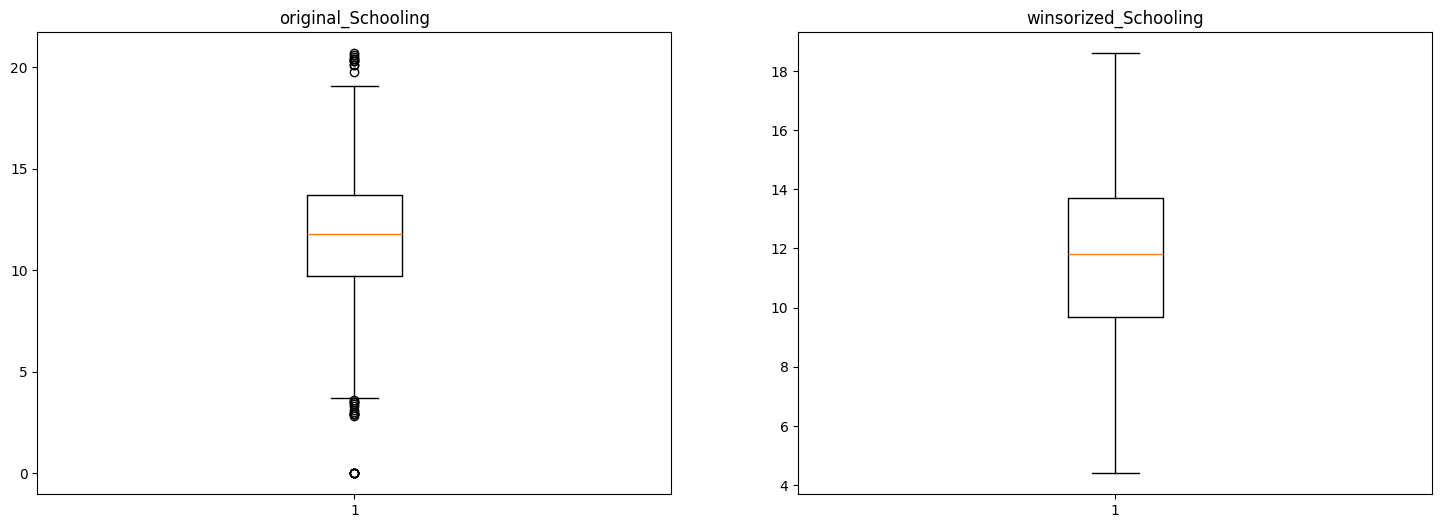

In [48]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
original_Schooling = le['Schooling']
plt.boxplot(original_Schooling)
plt.title("original_Schooling")

plt.subplot(1,2,2)
winsorized_Schooling = winsorize(le['Schooling'],(0.02,0.01))
plt.boxplot(winsorized_Schooling)
plt.title("winsorized_Schooling")

plt.show()

In [50]:
le['winsorized_Life_Expectancy'] = winsorized_Life_Expectancy
le['winsorized_Adult_Mortality'] = winsorized_Adult_Mortality
le['winsorized_Infant_Deaths'] = winsorized_Infant_Deaths
le['winsorized_Alcohol'] = winsorized_Alcohol
le['winsorized_Percentage_Exp'] = winsorized_Percentage_Exp
le['winsorized_HepatitisB'] = winsorized_HepatitisB
le['winsorized_Under_Five_Deaths'] = winsorized_Under_Five_Deaths
le['winsorized_Polio'] = winsorized_Polio
le['winsorized_Tot_Exp'] = winsorized_Tot_Exp
le['winsorized_Diphtheria'] = winsorized_Diphtheria
le['winsorized_HIV'] = winsorized_HIV
le['winsorized_GDP'] = winsorized_GDP
le['winsorized_Population'] = winsorized_Population
le['winsorized_thinness_1to19_years'] = winsorized_thinness_1to19_years
le['winsorized_thinness_5to9_years'] = winsorized_thinness_5to9_years
le['winsorized_Income_Comp_Of_Resources'] = winsorized_Income_Comp_Of_Resources
le['winsorized_Schooling'] = winsorized_Schooling

le.describe()

c:\Users\kseni\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\kseni\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\kseni\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\kseni\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\kseni\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


,Year,Life_Expectancy,Adult_Mortality,Infant_Deaths,Alcohol,Percentage_Exp,HepatitisB,BMI,Under_Five_Deaths,Polio,...,winsorized_Polio,winsorized_Tot_Exp,winsorized_Diphtheria,winsorized_HIV,winsorized_GDP,winsorized_Population,winsorized_thinness_1to19_years,winsorized_thinness_5to9_years,winsorized_Income_Comp_Of_Resources,winsorized_Schooling
count,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,...,1849.000000,1849.000000,1849.000000,1849.000000,1849.000000,1.849000e+03,1849.000000,1849.000000,1849.000000,1849.000000
mean,2006.964846,67.865224,175.843699,37.090860,4.374903,677.262172,73.714440,36.133748,51.554895,80.451595,...,83.002163,5.889162,83.219578,0.885992,2777.352079,4.850890e+06,5.052623,5.121363,0.613165,11.618496
std,4.325545,9.701858,131.349571,138.958391,3.944041,1757.413463,29.006187,19.728856,188.865542,24.008881,...,17.264306,2.282472,17.143096,1.187882,3036.177567,6.278267e+06,4.250330,4.330958,0.175335,3.113564
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,2.000000,1.400000,0.000000,3.000000,...,45.000000,0.370000,45.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.270000,4.400000
25%,2003.000000,61.400000,76.000000,1.000000,0.790000,29.520799,64.000000,18.000000,1.000000,74.000000,...,74.000000,4.360000,75.000000,0.100000,386.328828,1.912660e+05,1.700000,1.700000,0.469000,9.700000
50%,2007.000000,69.700000,154.000000,4.000000,3.640000,103.371069,86.000000,37.800000,4.000000,91.000000,...,91.000000,5.780000,91.000000,0.100000,1326.668820,1.396985e+06,3.500000,3.500000,0.644000,11.800000
75%,2011.000000,74.600000,247.000000,25.000000,7.040000,469.390419,95.000000,54.900000,37.000000,96.000000,...,96.000000,7.390000,96.000000,1.500000,4437.178680,7.815949e+06,7.700000,7.800000,0.741000,13.700000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,18961.348600,99.000000,76.700000,2500.000000,99.000000,...,99.000000,11.790000,99.000000,3.200000,8787.613750,1.715336e+07,16.100000,16.700000,0.936000,18.600000


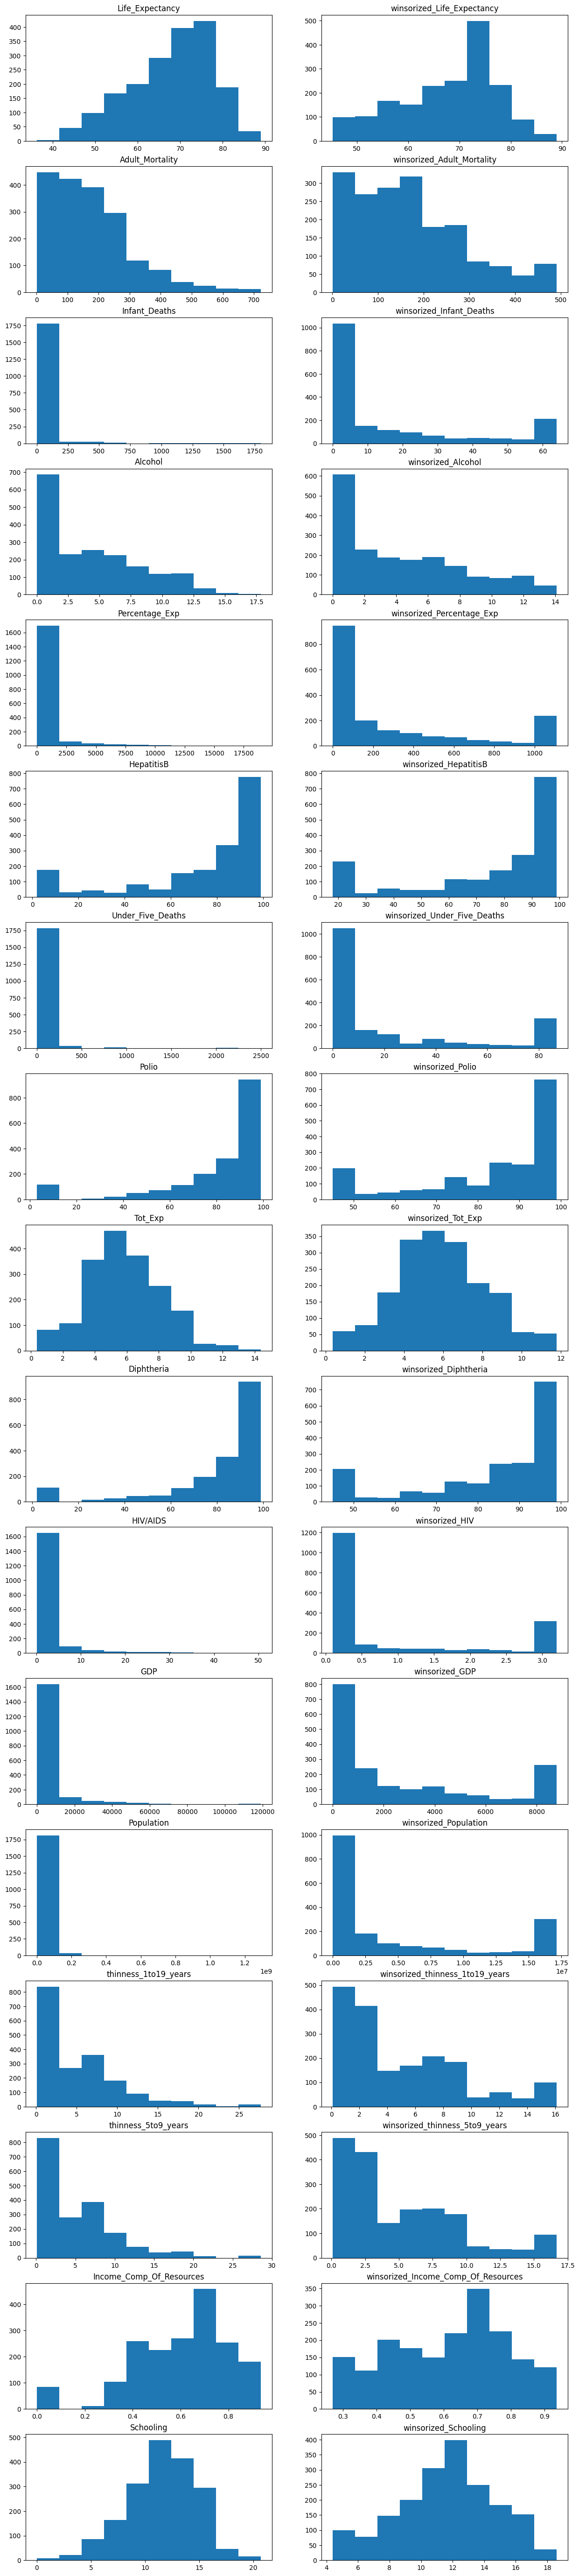

In [51]:
all_col = ['Life_Expectancy','winsorized_Life_Expectancy','Adult_Mortality','winsorized_Adult_Mortality','Infant_Deaths',
         'winsorized_Infant_Deaths','Alcohol','winsorized_Alcohol','Percentage_Exp','winsorized_Percentage_Exp','HepatitisB',
         'winsorized_HepatitisB','Under_Five_Deaths','winsorized_Under_Five_Deaths','Polio','winsorized_Polio','Tot_Exp',
         'winsorized_Tot_Exp','Diphtheria','winsorized_Diphtheria','HIV/AIDS','winsorized_HIV','GDP','winsorized_GDP',
         'Population','winsorized_Population','thinness_1to19_years','winsorized_thinness_1to19_years','thinness_5to9_years',
         'winsorized_thinness_5to9_years','Income_Comp_Of_Resources','winsorized_Income_Comp_Of_Resources',
         'Schooling','winsorized_Schooling']

plt.figure(figsize=(15,75))

for i in range(len(all_col)):
    plt.subplot(18,2,i+1)
    plt.hist(le[all_col[i]])
    plt.title(all_col[i])

plt.show()

In [52]:
#Смотрим статистику для интерполированных свойств
#Самая частая страна - Афганистан, всего уникальных стран - 133, в таблице записано 1849 значений
#Афганистан встречается 15 раз.
#Самый популярный статус - развивающаяся страна, это значение встречается 1598 раз из 1849
le.describe(include=['O'])

,Country,Status
count,1849,1849
unique,133,2
top,Afghanistan,Developing
freq,15,1598


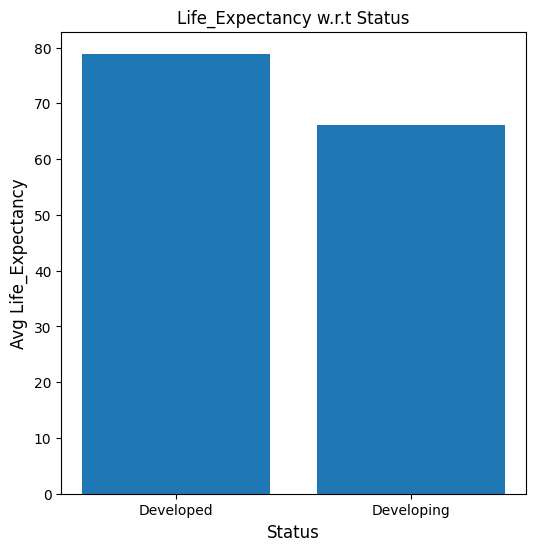

In [53]:
plt.figure(figsize=(6,6))
plt.bar(le.groupby('Status')['Status'].count().index,le.groupby('Status')['winsorized_Life_Expectancy'].mean())
plt.xlabel("Status",fontsize=12)
plt.ylabel("Avg Life_Expectancy",fontsize=12)
plt.title("Life_Expectancy w.r.t Status")
plt.show()

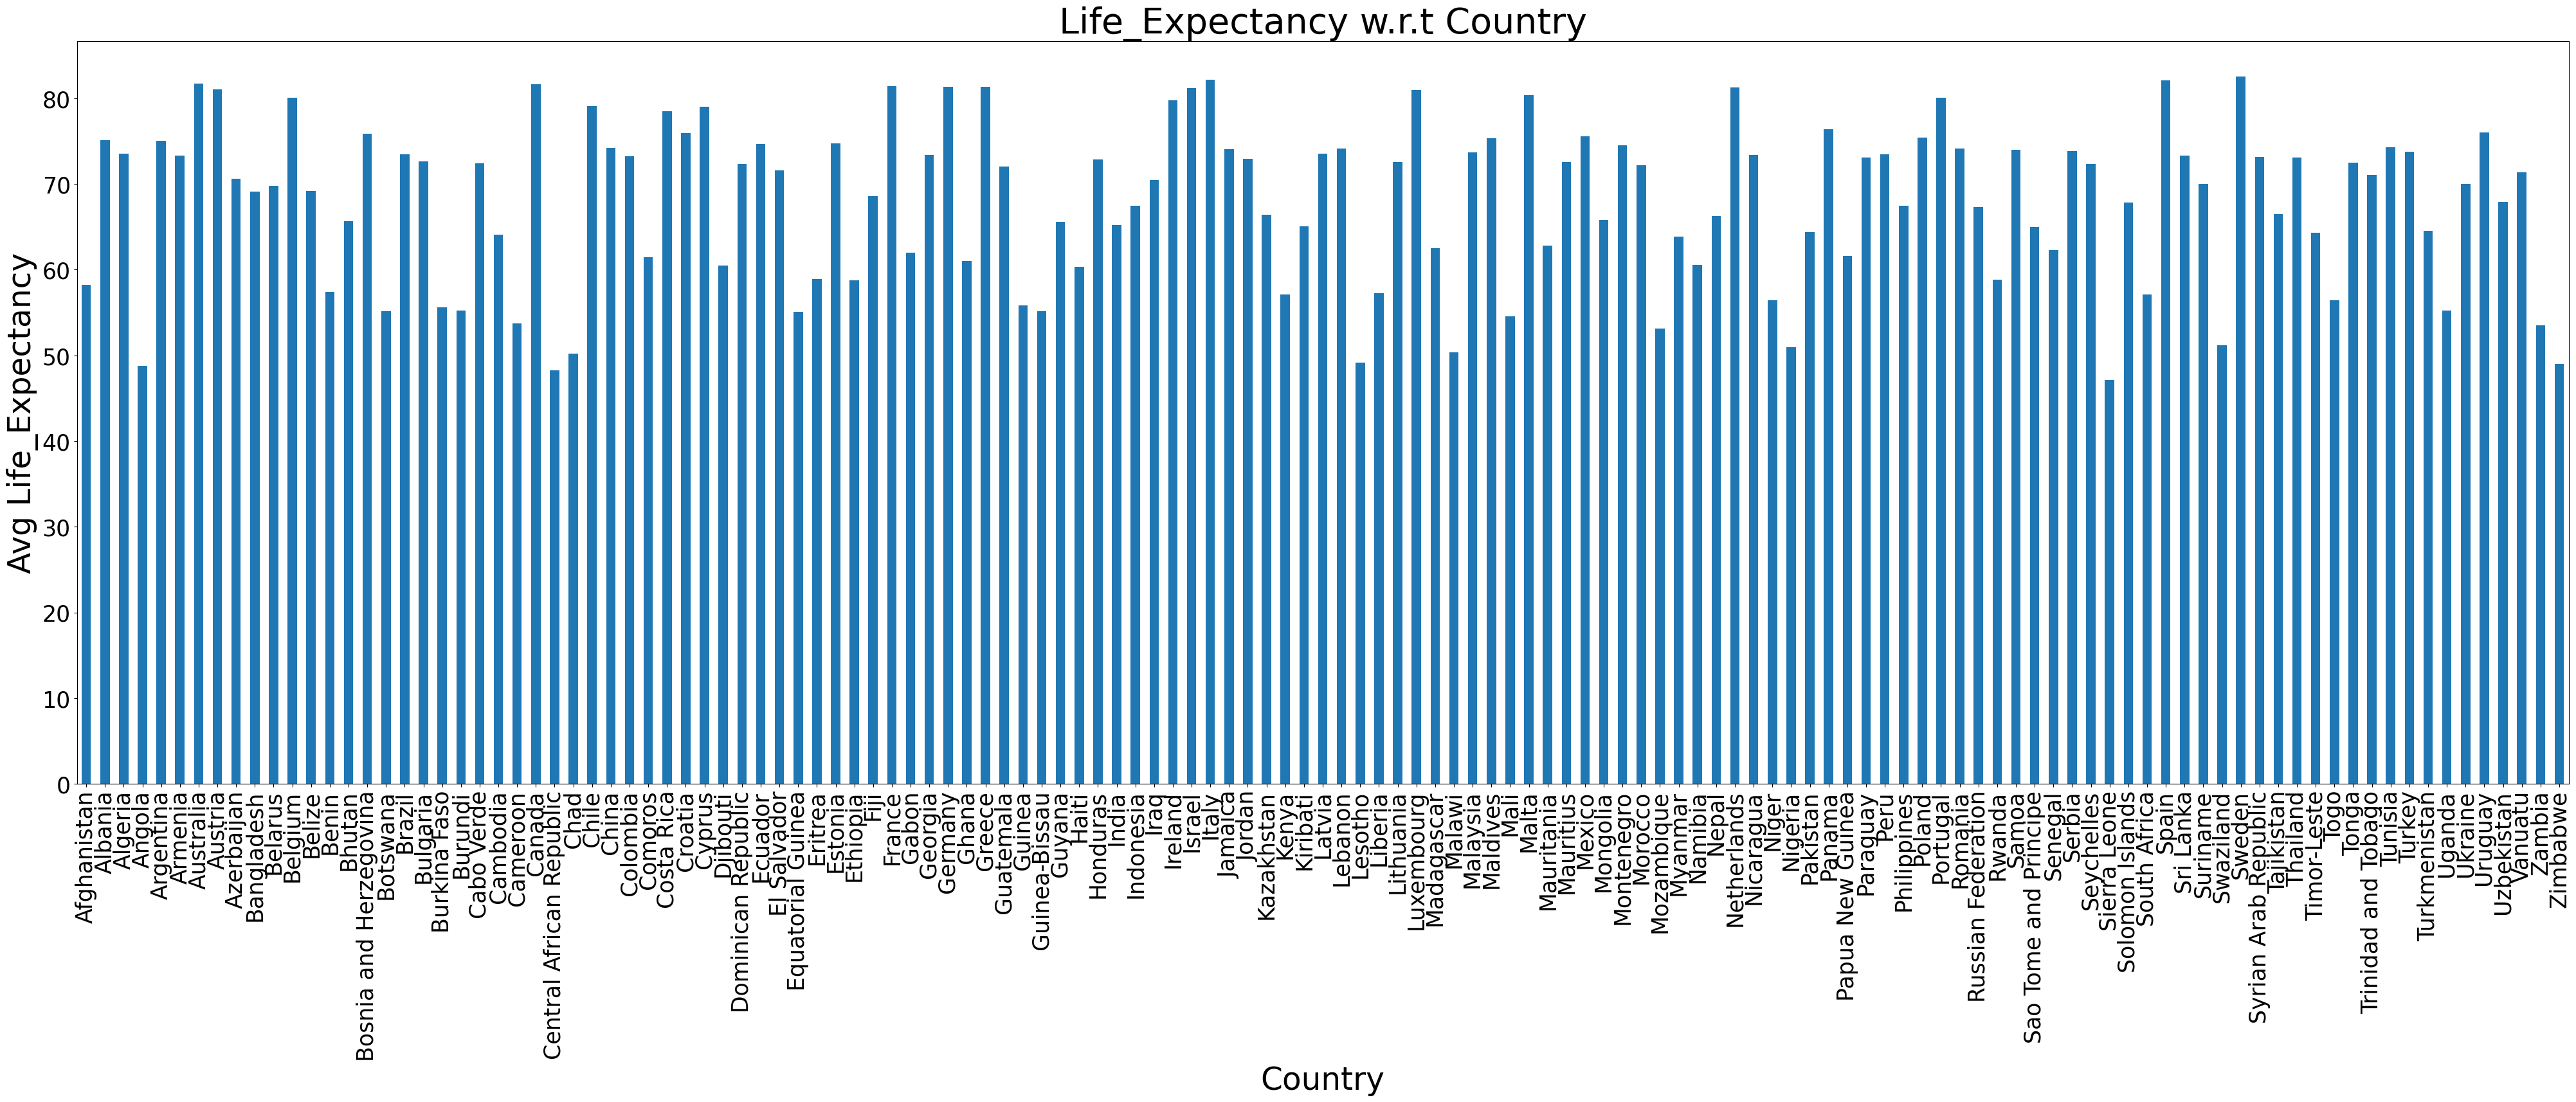

In [54]:
le_country = le.groupby('Country')['winsorized_Life_Expectancy'].mean()
le_country.plot(kind='bar', figsize=(50,15), fontsize=25)
plt.title("Life_Expectancy w.r.t Country",fontsize=40)
plt.xlabel("Country",fontsize=35)
plt.ylabel("Avg Life_Expectancy",fontsize=35)
plt.show()

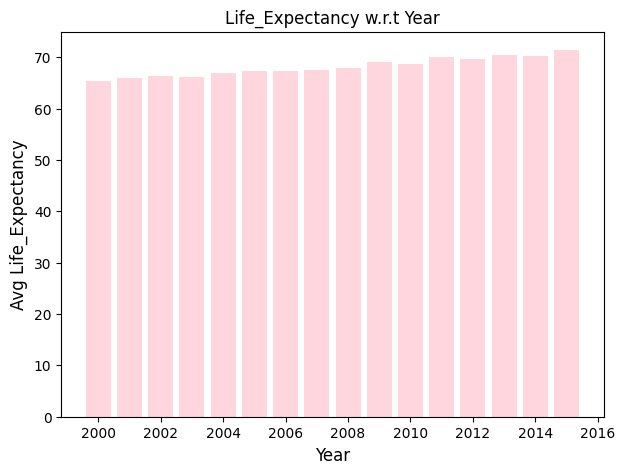

In [55]:
plt.figure(figsize=(7,5))
plt.bar(le.groupby('Year')['Year'].count().index,le.groupby('Year')['winsorized_Life_Expectancy'].mean(),color='pink',alpha=0.65)
plt.xlabel("Year",fontsize=12)
plt.ylabel("Avg Life_Expectancy",fontsize=12)
plt.title("Life_Expectancy w.r.t Year")
plt.show()

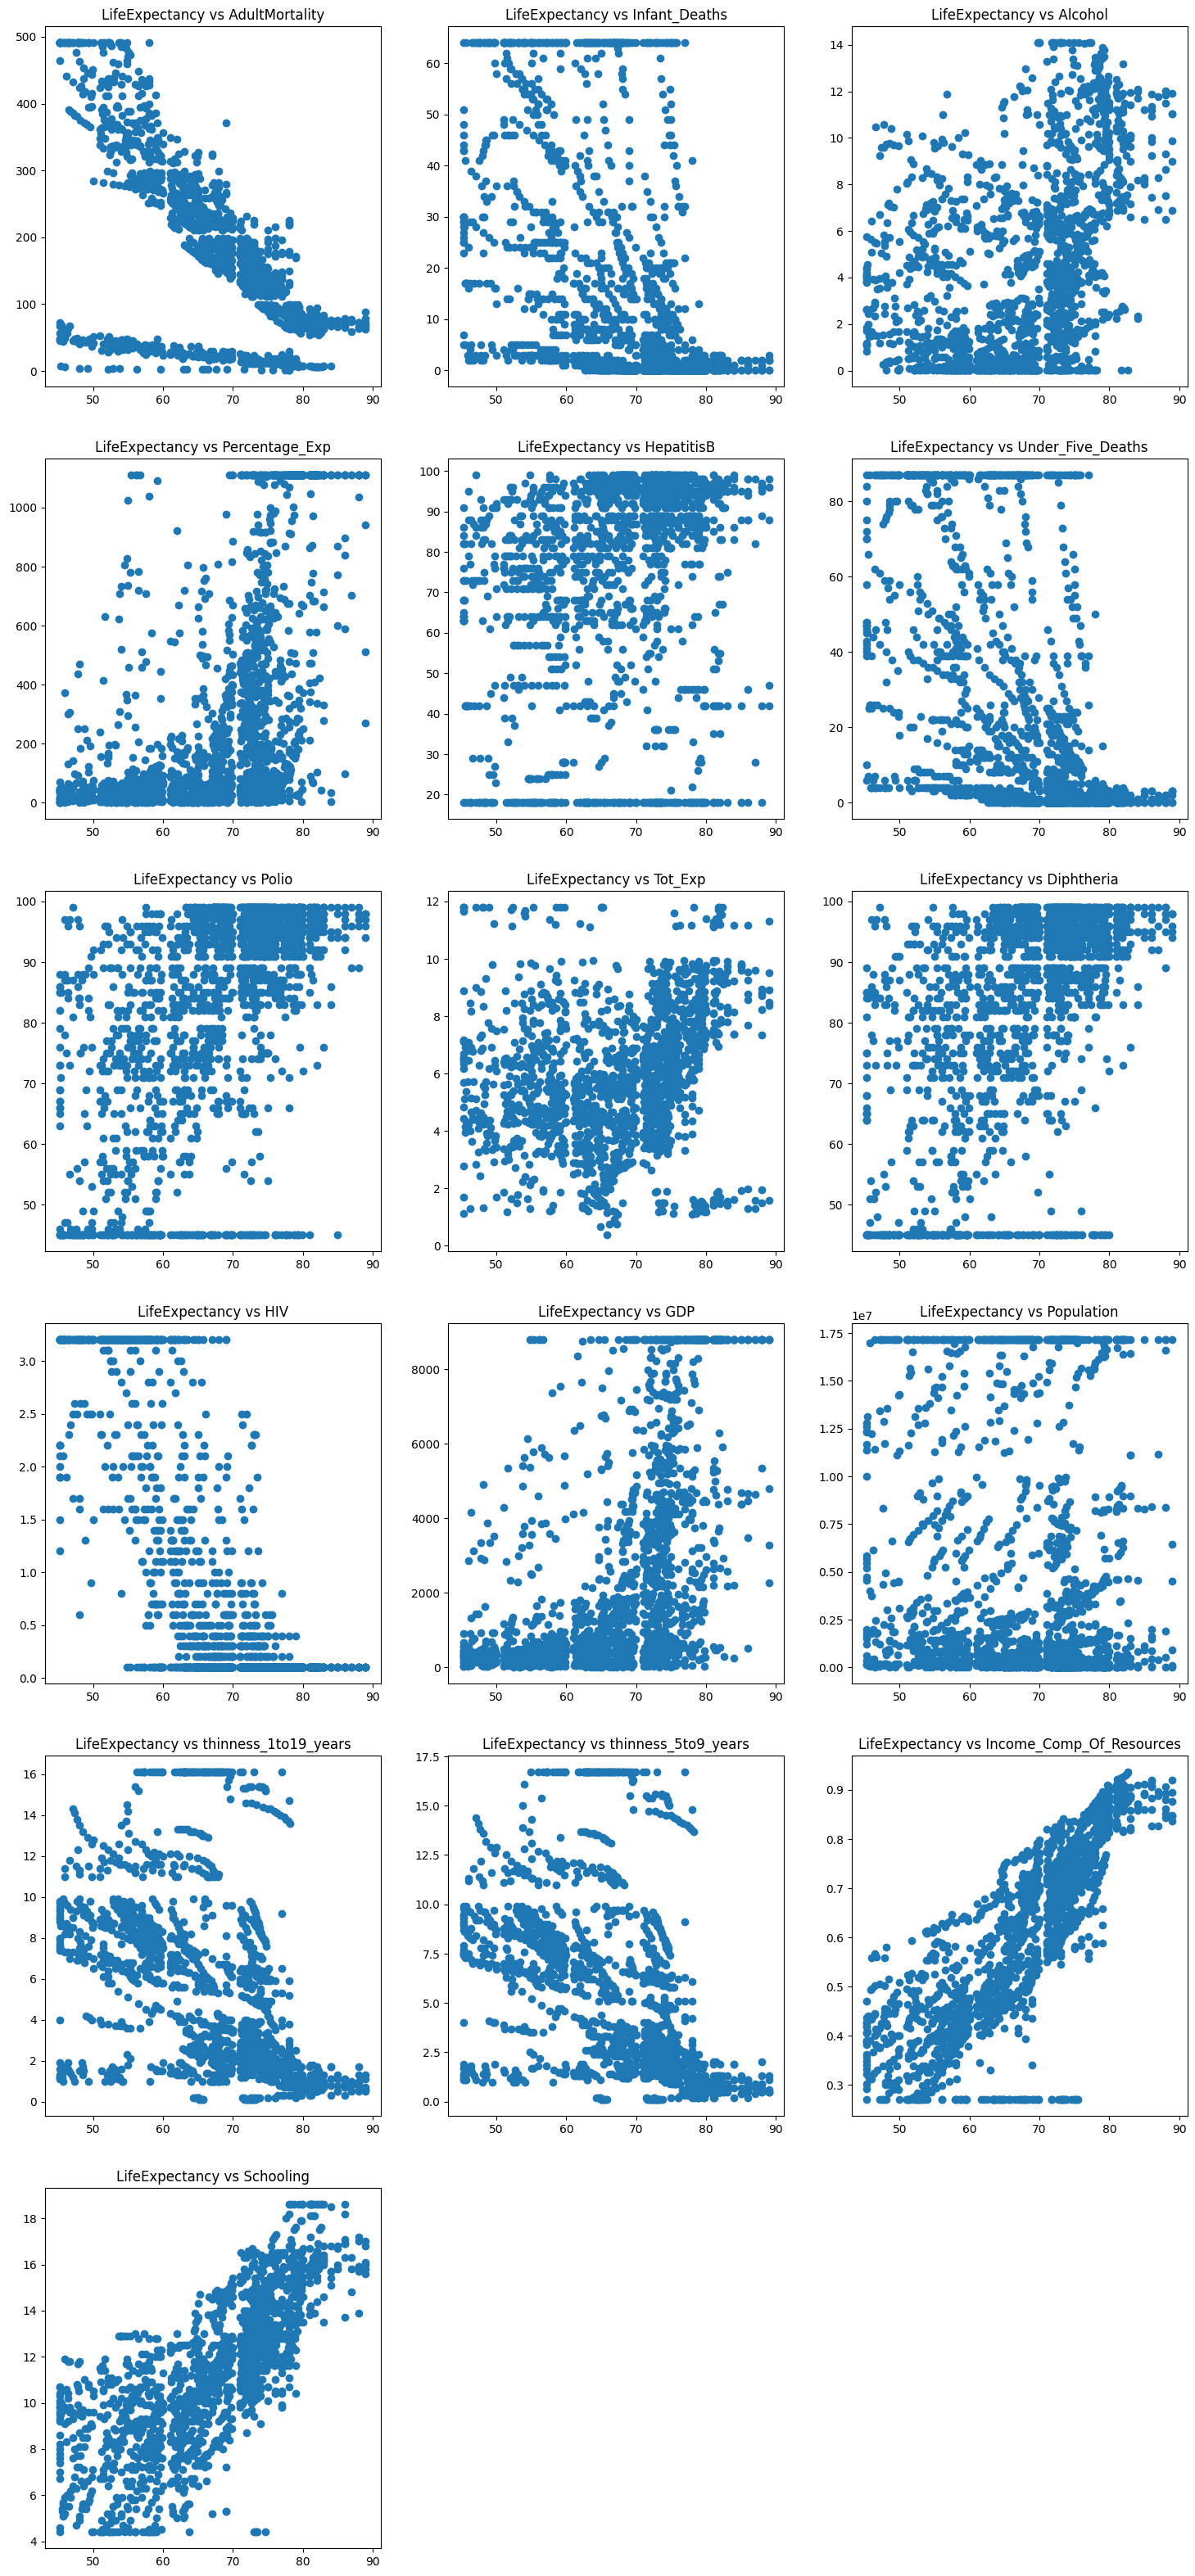

In [56]:
plt.figure(figsize=(18,40))

plt.subplot(6,3,1)
plt.scatter(le["winsorized_Life_Expectancy"], le["winsorized_Adult_Mortality"])
plt.title("LifeExpectancy vs AdultMortality")

plt.subplot(6,3,2)
plt.scatter(le["winsorized_Life_Expectancy"], le["winsorized_Infant_Deaths"])
plt.title("LifeExpectancy vs Infant_Deaths")

plt.subplot(6,3,3)
plt.scatter(le["winsorized_Life_Expectancy"], le["winsorized_Alcohol"])
plt.title("LifeExpectancy vs Alcohol")

plt.subplot(6,3,4)
plt.scatter(le["winsorized_Life_Expectancy"], le["winsorized_Percentage_Exp"])
plt.title("LifeExpectancy vs Percentage_Exp")

plt.subplot(6,3,5)
plt.scatter(le["winsorized_Life_Expectancy"], le["winsorized_HepatitisB"])
plt.title("LifeExpectancy vs HepatitisB")

plt.subplot(6,3,6)
plt.scatter(le["winsorized_Life_Expectancy"], le["winsorized_Under_Five_Deaths"])
plt.title("LifeExpectancy vs Under_Five_Deaths")

plt.subplot(6,3,7)
plt.scatter(le["winsorized_Life_Expectancy"], le["winsorized_Polio"])
plt.title("LifeExpectancy vs Polio")

plt.subplot(6,3,8)
plt.scatter(le["winsorized_Life_Expectancy"], le["winsorized_Tot_Exp"])
plt.title("LifeExpectancy vs Tot_Exp")

plt.subplot(6,3,9)
plt.scatter(le["winsorized_Life_Expectancy"], le["winsorized_Diphtheria"])
plt.title("LifeExpectancy vs Diphtheria")

plt.subplot(6,3,10)
plt.scatter(le["winsorized_Life_Expectancy"], le["winsorized_HIV"])
plt.title("LifeExpectancy vs HIV")

plt.subplot(6,3,11)
plt.scatter(le["winsorized_Life_Expectancy"], le["winsorized_GDP"])
plt.title("LifeExpectancy vs GDP")

plt.subplot(6,3,12)
plt.scatter(le["winsorized_Life_Expectancy"], le["winsorized_Population"])
plt.title("LifeExpectancy vs Population")

plt.subplot(6,3,13)
plt.scatter(le["winsorized_Life_Expectancy"], le["winsorized_thinness_1to19_years"])
plt.title("LifeExpectancy vs thinness_1to19_years")

plt.subplot(6,3,14)
plt.scatter(le["winsorized_Life_Expectancy"], le["winsorized_thinness_5to9_years"])
plt.title("LifeExpectancy vs thinness_5to9_years")

plt.subplot(6,3,15)
plt.scatter(le["winsorized_Life_Expectancy"], le["winsorized_Income_Comp_Of_Resources"])
plt.title("LifeExpectancy vs Income_Comp_Of_Resources")

plt.subplot(6,3,16)
plt.scatter(le["winsorized_Life_Expectancy"], le["winsorized_Schooling"])
plt.title("LifeExpectancy vs Schooling")


plt.show()

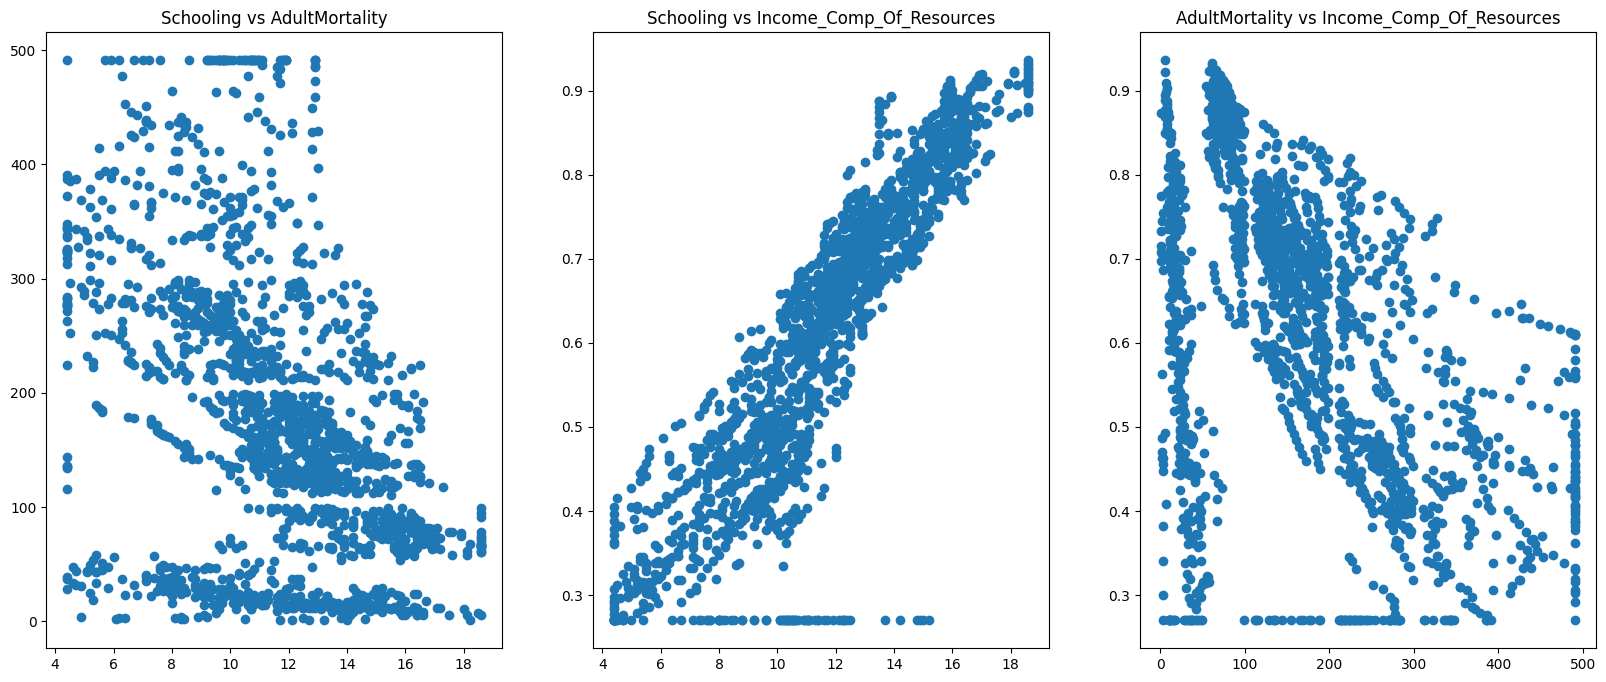

In [57]:
#Было замечено, что продолжительность жизни имеет негативную кореляцию со свойством Взрослая Смертность
#А также позитивную кореляцию со свойством Образование и Конкуренция по доходам
#Было принято решение просмотреть их соотнешение друг с другом.
plt.figure(figsize=(20,8))

plt.subplot(1,3,1)
plt.scatter(le["winsorized_Schooling"], le["winsorized_Adult_Mortality"])
plt.title("Schooling vs AdultMortality")

plt.subplot(1,3,2)
plt.scatter(le["winsorized_Schooling"], le["winsorized_Income_Comp_Of_Resources"])
plt.title("Schooling vs Income_Comp_Of_Resources")

plt.subplot(1,3,3)
plt.scatter(le["winsorized_Adult_Mortality"], le["winsorized_Income_Comp_Of_Resources"])
plt.title("AdultMortality vs Income_Comp_Of_Resources")

plt.show()

In [58]:
#Заметно, что они как-то взаимосвязаны, проверим с помощью тепловой карты.
le_win = le.iloc[:,21:]
le_win['Country'] = le['Country']
le_win['Year'] = le['Year']
le_win['Status'] = le['Status']
le_win_num = le_win.iloc[:,:-3]
cormat = le_win_num.corr()

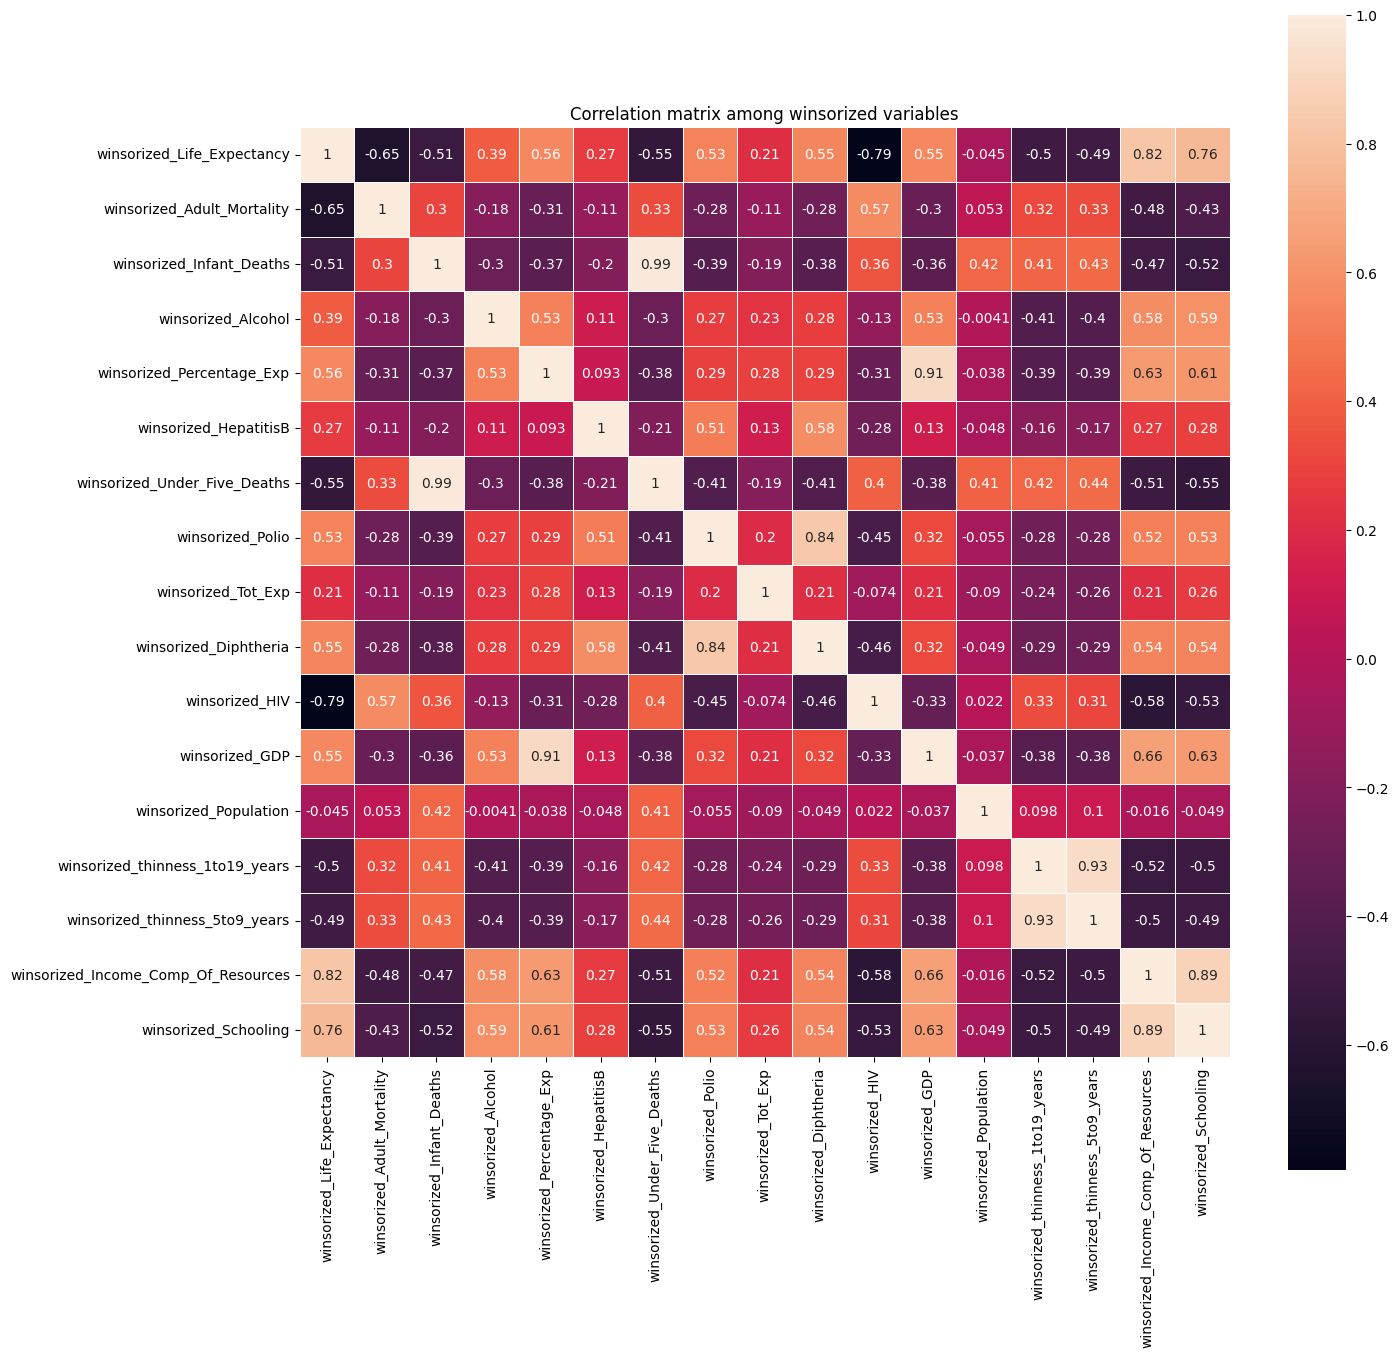

In [59]:
plt.figure(figsize=(15,15))
sns.heatmap(cormat, square=True, annot=True, linewidths=.5)
plt.title("Correlation matrix among winsorized variables")
plt.show()

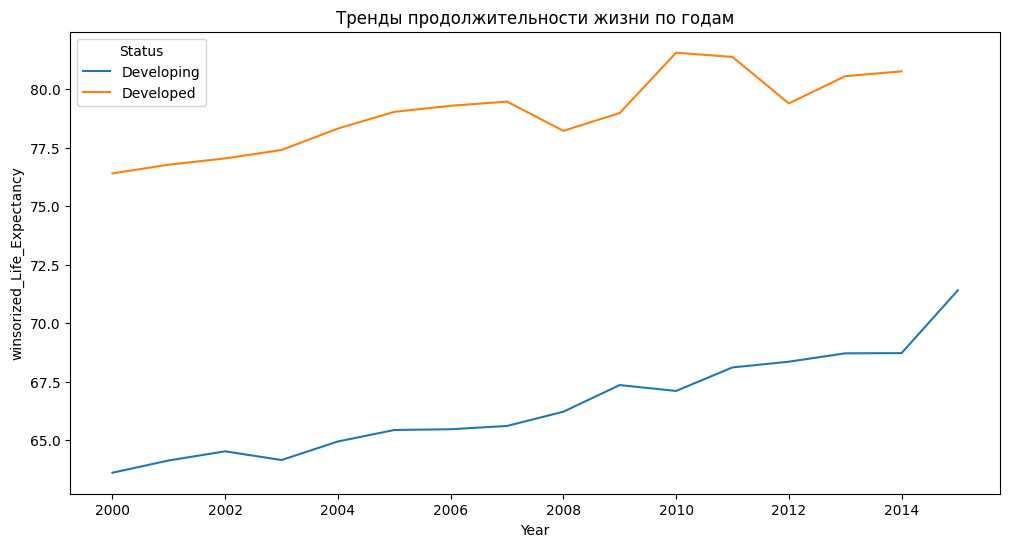

In [63]:
# 7. Временные тренды для продолжительности жизни
if 'Year' in le.columns and 'winsorized_Life_Expectancy' in le.columns:
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='Year', y='winsorized_Life_Expectancy', data=le, hue='Status', errorbar=None)
    plt.title('Тренды продолжительности жизни по годам')
    plt.show()

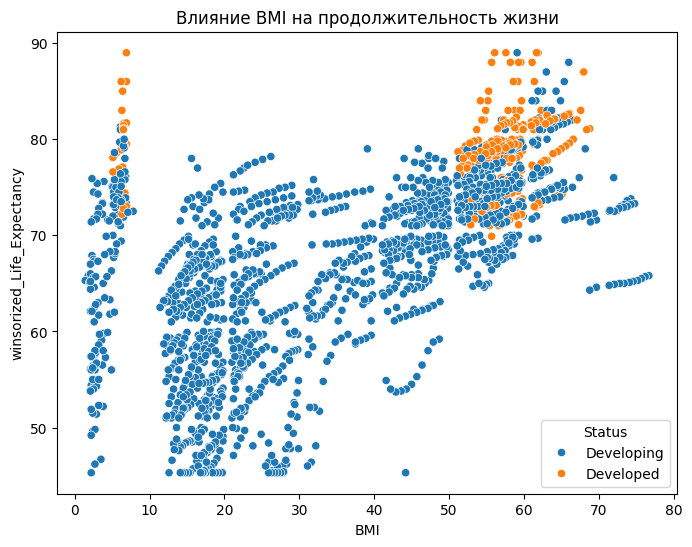

In [68]:
# 10. Анализ распределения BMI и его влияние на продолжительность жизни
if 'BMI' in le.columns and 'winsorized_Life_Expectancy' in le.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='BMI', y='winsorized_Life_Expectancy', data=le, hue='Status')
    plt.title('Влияние BMI на продолжительность жизни')
    plt.show()


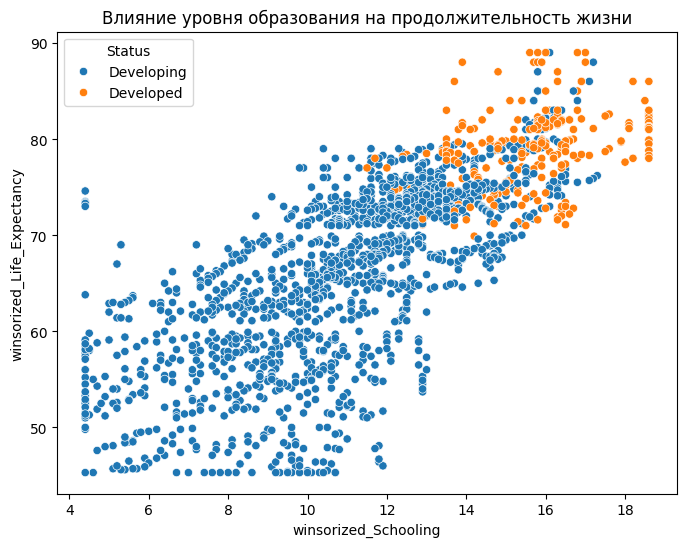

In [71]:
# 11. Анализ уровня образования и продолжительности жизни
if 'winsorized_Schooling' in le.columns and 'winsorized_Life_Expectancy' in le.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='winsorized_Schooling', y='winsorized_Life_Expectancy', data=le, hue='Status')
    plt.title('Влияние уровня образования на продолжительность жизни')
    plt.show()


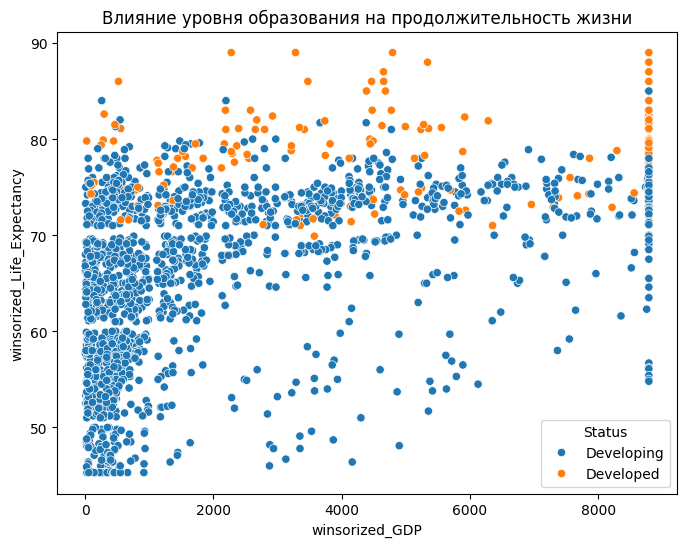

In [72]:
if 'winsorized_GDP' in le.columns and 'winsorized_Life_Expectancy' in le.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='winsorized_GDP', y='winsorized_Life_Expectancy', data=le, hue='Status')
    plt.title('Влияние уровня образования на продолжительность жизни')
    plt.show()

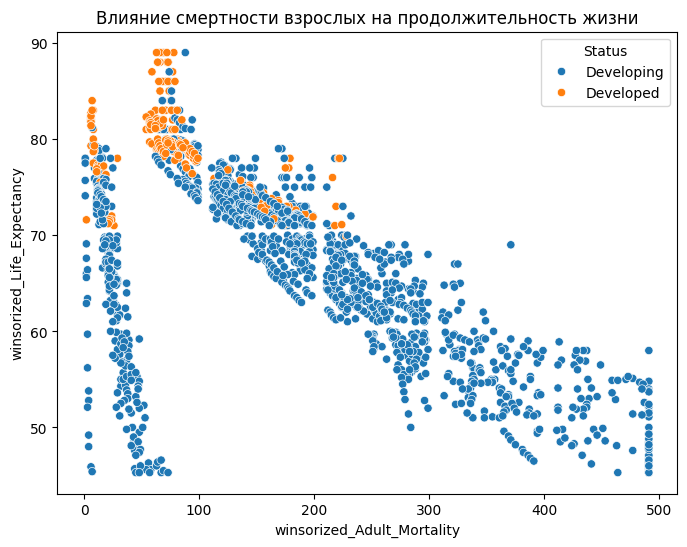

In [73]:
# 13. Исследование смертности и её влияния
if 'winsorized_Adult_Mortality' in le.columns and 'winsorized_Life_Expectancy' in le.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='winsorized_Adult_Mortality', y='winsorized_Life_Expectancy', data=le, hue='Status')
    plt.title('Влияние смертности взрослых на продолжительность жизни')
    plt.show()

In [74]:
# Добавление новых признаков
if 'winsorized_Income_Comp_Of_Resources' in le.columns and 'winsorized_Schooling' in le.columns:
    le['Economic_health_index'] = le['winsorized_Income_Comp_Of_Resources'] * le['winsorized_Schooling']

if 'winsorized_Tot_Exp' in le.columns and 'GDP' in le.columns:
    le['Health_expenditure_ratio'] = le['winsorized_Tot_Exp'] / le['GDP']

if 'winsorized_Adult_Mortality' in le.columns and 'winsorized_Under_Five_Deaths' in le.columns:
    le['Mortality_rate_ratio'] = le['winsorized_Adult_Mortality'] / le['winsorized_Under_Five_Deaths']

# Просмотр обновлённого датасета
print(le.T.head(41))


                                            0            1            2     \
Country                              Afghanistan  Afghanistan  Afghanistan   
Year                                        2015         2014         2013   
Status                                Developing   Developing   Developing   
Life_Expectancy                             65.0         59.9         59.9   
Adult_Mortality                            263.0        271.0        268.0   
Infant_Deaths                                 62           64           66   
Alcohol                                     0.01         0.01         0.01   
Percentage_Exp                         71.279624    73.523582    73.219243   
HepatitisB                                  65.0         62.0         64.0   
BMI                                         19.1         18.6         18.1   
Under_Five_Deaths                             83           86           89   
Polio                                        6.0         58.0   

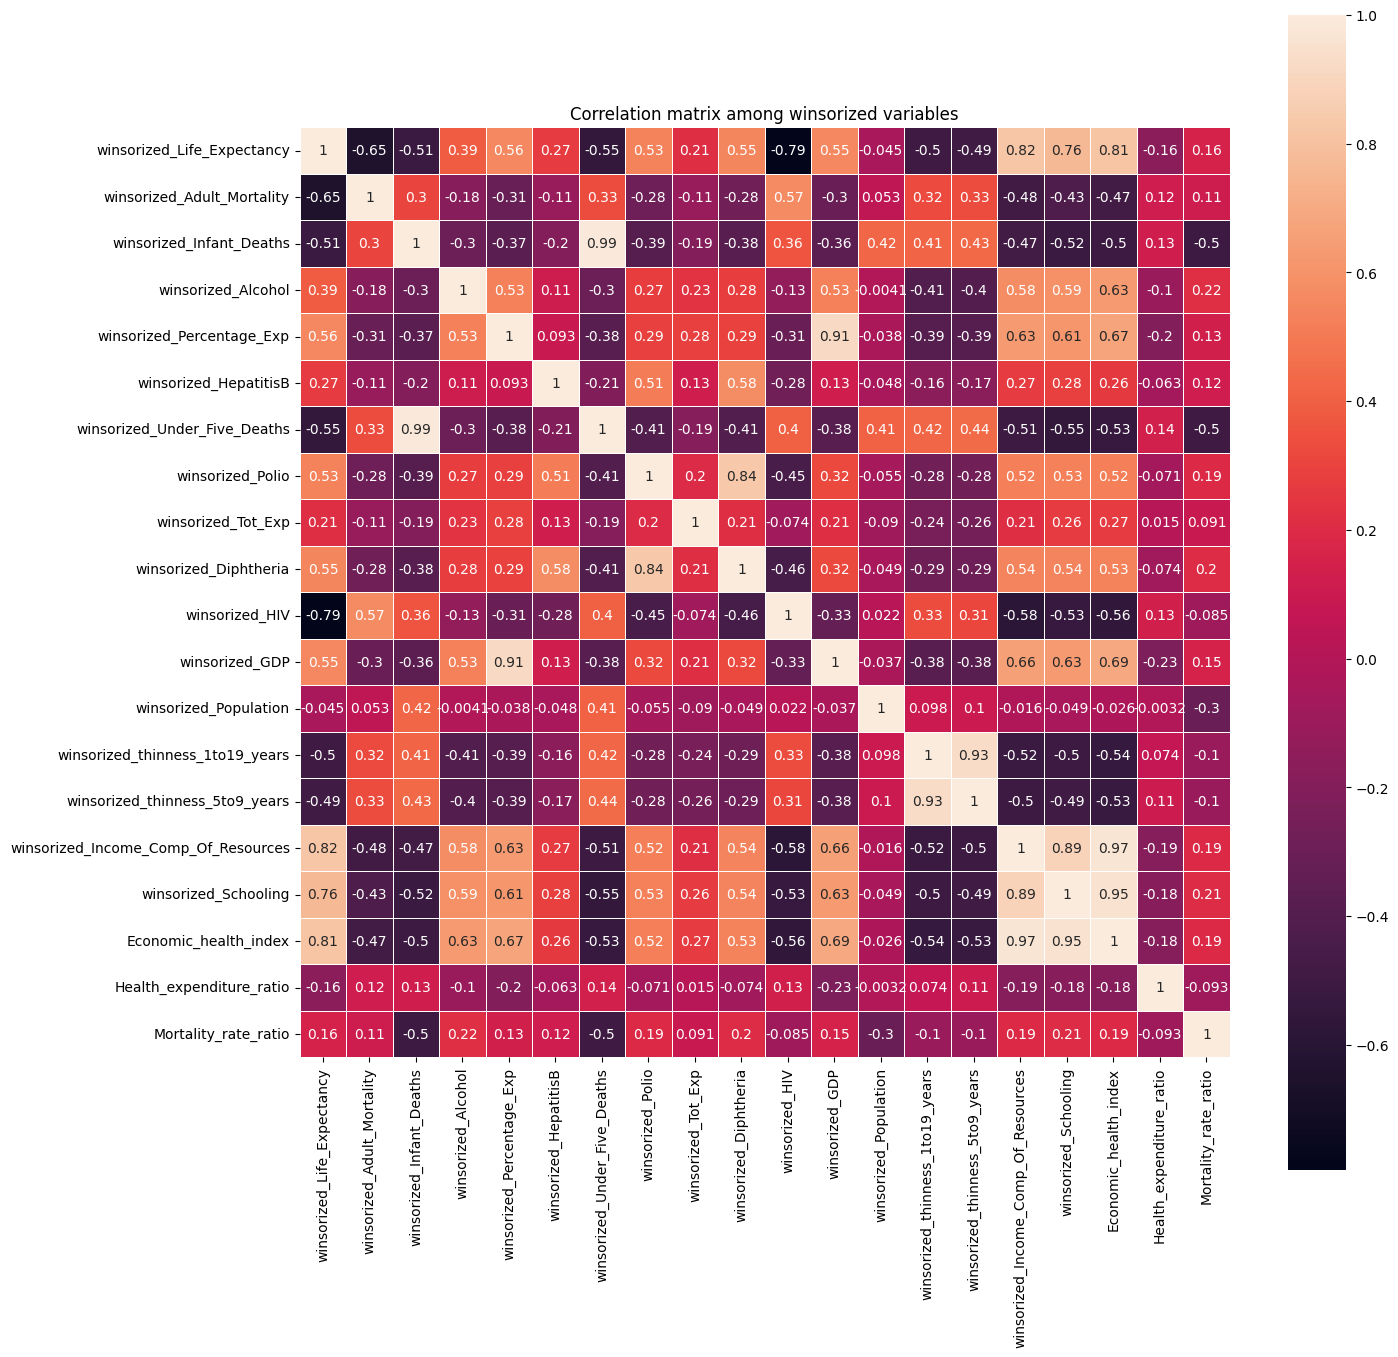

In [75]:
# Построение новой корреляционной матрицы
le_win = le.iloc[:,21:]
le_win['Country'] = le['Country']
le_win['Year'] = le['Year']
le_win['Status'] = le['Status']
le_win_num = le_win.iloc[:,:-3]
cormat = le_win_num.corr()

plt.figure(figsize=(15,15))
sns.heatmap(cormat, square=True, annot=True, linewidths=.5)
plt.title("Correlation matrix among winsorized variables")
plt.show()


In [76]:
data_cleaned = le

In [77]:
data_cleaned = data_cleaned.round(3)
output_file = 'final_dataset.csv'
data_cleaned.to_csv(output_file, index=False)